In [33]:
import rioxarray as rxr
import xarray as xr
from pyproj import Transformer
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import glob
import numpy as np
from matplotlib.animation import FuncAnimation
from rasterio.enums import Resampling
import pandas as pd
import os
from pathlib import Path

In [34]:
root = Path(".").resolve()
project_root = root if (root / "Notebooks").exists() else root.parent
out_dir = project_root / "Subglacial_Lakes_Data"

df = pd.read_csv(out_dir/"lake_and_null_loc.csv")
df

,name,lon,lat
0,Adams17,110.090000,-67.020000
1,Adams19,109.650000,-67.090000
2,Amery22,66.280000,-72.700000
3,ANZAC19,109.420000,-67.080000
4,Beardmore107,168.320000,-84.700000
...,...,...,...
100,null_15,120.972053,-68.446489
101,null_16,84.995256,-72.512985
102,null_17,111.352840,-68.629307
103,null_18,161.051311,-76.428144


In [35]:
remaMosaicPath = r"/Users/Ashley Howard/ESS569/rema_mosaic_100m_v2.0_dem.tif"
cryosatPath = r"/Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/cryosat_downloads/CS_OFFL_THEM_GRID__ANTARCTIC_" 

In [36]:
years = np.arange(2011, 2020) 
yearsString = [str(year) for year in years]
months = np.arange(1, 13)
monthsString = [str(month).zfill(2) for month in months]
allTime = ['2010_08', '2010_09', '2010_10', '2010_11', '2010_12']+[year + "_" + month for year in yearsString for month in monthsString]

In [37]:
rema = rxr.open_rasterio(remaMosaicPath, masked=True).squeeze()

In [38]:

def monthlyAnomaly(rema, date, long, lat):
    # Import CryoSat Data
    file_path = cryosatPath + date + "_V201.nc"

    # segment added using ChatGPT to deal with Windows file permissions errors
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return None   # exit function safely

    with xr.open_dataset(file_path) as ds:
        elevation = ds['elevation'].transpose('time', 'y', 'x')
        # Find Center of the Lake
        transformer = Transformer.from_crs(
            "EPSG:4326",   # lat/lon
            "EPSG:3031",   # Antarctic Polar Stereo
            always_xy=True
        )

        x_center, y_center = transformer.transform(long, lat)

        # Define Bounding Box Around Center of the Lake
        half_size = 25_000  # 25 (edit)

        xmin = x_center - half_size
        xmax = x_center + half_size
        ymin = y_center - half_size
        ymax = y_center + half_size

    # Pull Boxes for CryoSat & REMA
        cryosat_small = elevation.sel(x=slice(xmin, xmax), y=slice(ymin, ymax))
        rema_small = rema.rio.clip_box(xmin,ymin,xmax,ymax)

        # Calculate Anomaly in Cryosat Based on REMA
        cryosat_small = cryosat_small.rio.write_crs("EPSG:3031")
        cryosat_small = cryosat_small.rio.set_spatial_dims(x_dim="x", y_dim="y")

        # Regrid Cryosat (2km) to match REMA (100 m) using nearest-neighbor
        cryosat_small_r = cryosat_small.rio.reproject_match(rema_small, resampling=Resampling.bilinear)

            # commented out bc no longer projecting to cryosat
    #rema_small = rema_small.rio.set_spatial_dims(x_dim="x", y_dim="y")
    #rema_matched = rema_small.rio.reproject_match(cryosat_small_r.isel(time=0)) 

        anomaly = cryosat_small_r.isel(time=0) - rema_small

    return anomaly

In [39]:
# locationAnomaly function altered using Microsoft Copilot to be more Windows file handling friendly

from __future__ import annotations

import os
import errno
import time
import tempfile
from pathlib import Path
from typing import Iterable

import xarray as xr

def locationAnomaly(longitude: float,
                    latitude: float,
                    file_path: str,
                    all_time: Iterable,
                    *,
                    output_dir: str = "lakesTS",
                    retries: int = 5,
                    backoff: float = 0.5) -> Path:
    """
    Build a time-stacked anomaly dataset and write to NetCDF with
    Windows-friendly, atomic & retrying write semantics.

    Parameters
    ----------
    longitude : float
    latitude : float
    file_path : str
        Base file name (without extension).
    all_time : iterable
        Iterable of datetime-like values passed to monthlyAnomaly(...).
    output_dir : str
        Target directory for output NetCDF.
    retries : int
        Max attempts for handling PermissionError / EACCES.
    backoff : float
        Initial backoff in seconds; doubles each retry.

    Returns
    -------
    Path
        The final path to the written NetCDF.
    """
    # 1) Compute the stacked anomalies first (fail fast before file ops)
    dataarrays = []
    for date in all_time:
        da = monthlyAnomaly(rema, date, longitude, latitude)  # assumes these exist in your environment
        dataarrays.append(da)
    dataarrays = [da for da in dataarrays if da is not None]
    stacked = xr.concat(dataarrays, dim="time")
    ds = xr.Dataset({"anomaly": stacked})

    # 2) Ensure output directory exists (handle permissions here too)
    out_dir = Path(output_dir)
    try:
        out_dir.mkdir(parents=True, exist_ok=True)
    except PermissionError as e:
        raise PermissionError(
            f"Cannot create or access directory: {out_dir}. "
            f"Check write permissions or try a different location."
        ) from e

    # 3) Build a sanitized destination path
    #    (Windows doesn't like certain characters in filenames)
    safe_name = _sanitize_filename(file_path)
    dest_path = out_dir / f"{safe_name}.nc"

    # 4) Atomic write: write to a closed temp file, then os.replace()
    #    (on Windows, NamedTemporaryFile must be closed before reuse)
    attempt = 0
    tmp_path: Path | None = None
    try:
        while True:
            try:
                with tempfile.NamedTemporaryFile(
                    mode="wb",
                    suffix=".nc",
                    prefix=f".{safe_name}.tmp.",
                    dir=str(out_dir),
                    delete=False  # we will clean up explicitly
                ) as tmp:
                    tmp_path = Path(tmp.name)

                # Use a separate handle to ensure xarray closes properly before replace
                # If your arrays are dask-backed, consider compute() before write for predictability:
                # ds = ds.compute()
                # Use a lock-free write; xarray handles locking internally for netCDF4/h5netcdf engines
                ds.to_netcdf(tmp_path, mode="w")

                # Force data flush & close before replace
                ds.close()

                # Atomic move into final place
                os.replace(tmp_path, dest_path)
                return dest_path

            except PermissionError as e:
                # Windows: file in use, AV scanning, or no rights
                attempt += 1
                if attempt > retries:
                    _raise_with_context(e, dest_path, attempt)
                # Exponential backoff
                time.sleep(backoff)
                backoff *= 2
                continue

            except OSError as e:
                # Treat EACCES like PermissionError as well
                if e.errno in (errno.EACCES, errno.EPERM):
                    attempt += 1
                    if attempt > retries:
                        _raise_with_context(e, dest_path, attempt)
                    time.sleep(backoff)
                    backoff *= 2
                    continue
                # Other OS errors: bubble up
                raise

    finally:
        # Best-effort cleanup of temp file if it still exists
        try:
            if tmp_path and tmp_path.exists():
                tmp_path.unlink(missing_ok=True)
        except Exception:
            # Don't mask the original exception
            pass
        # Ensure dataset is closed even if an exception occurred
        try:
            ds.close()
        except Exception:
            pass


def _sanitize_filename(name: str) -> str:
    """
    Remove characters problematic on Windows: \\ / : * ? \" < > | and control chars.
    Also trims spaces & dots at the end which Windows disallows for names.
    """
    bad = '<>:"/\\|?*'
    cleaned = "".join(ch for ch in name if ch not in bad and ord(ch) >= 32)
    cleaned = cleaned.strip().rstrip(".")
    return cleaned or "output"


def _raise_with_context(e: BaseException, path: Path, attempts: int) -> None:
    raise PermissionError(
        "Failed to write NetCDF after multiple attempts.\n"
        f"Target: {path}\n"
        f"Attempts: {attempts}\n\n"
        "Possible causes on Windows:\n"
        "  • The file is open in another app (e.g., Excel, Panoply, Explorer preview).\n"
        "  • Antivirus or backup tools are temporarily locking the file.\n"
        "  • Insufficient permissions to the folder.\n"
        "  • Corporate policies (e.g., Controlled Folder Access) blocking writes.\n\n"
        "Try:\n"
        "  • Close any app that might be using the file.\n"
        "  • Write to a different directory (e.g., your user Documents folder).\n"
        "  • Disable the Explorer preview pane.\n"
        "  • Temporarily pause AV scanning on the folder (if allowed).\n"
        "  • Run Python as a user with write permissions.\n"
    ) from e


In [40]:
# Loop through rows
for _, row in df.iterrows():
    locationAnomaly(
        row["lon"],
        row["lat"],
        row["name"],
        allTime
    )

File not found: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/cryosat_downloads/CS_OFFL_THEM_GRID__ANTARCTIC_2015_01_V201.nc
File not found: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/cryosat_downloads/CS_OFFL_THEM_GRID__ANTARCTIC_2015_07_V201.nc
File not found: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/cryosat_downloads/CS_OFFL_THEM_GRID__ANTARCTIC_2015_01_V201.nc
File not found: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/cryosat_downloads/CS_OFFL_THEM_GRID__ANTARCTIC_2015_07_V201.nc
File not found: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/cryosat_downloads/CS_OFFL_THEM_GRID__ANTARCTIC_2015_01_V201.nc
File not found: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/cryosat_downloads/CS_OFFL_THEM_GRID__ANTARCTIC_2015_07_V201.nc
File not found: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/cryosat_downloads/CS_OFFL_THEM_GRID__ANTARCTIC_2015_01_

In [17]:
import os
import glob
import numpy as np
from sklearn.model_selection import train_test_split

# Folder containing netCDF files
data_dir = r"/Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lakesTS"

# Get all .nc files
files = sorted(glob.glob(os.path.join(data_dir, "*.nc")))

# Assign block IDs
block_ids = np.arange(len(files))

# First split: 70% train, 30% temp
train_files, temp_files = train_test_split(
    files,
    test_size=0.30,
    random_state=42,   # ensures reproducibility
    shuffle=True
)

# Second split: split the 30% into 15% val, 15% test
val_files, test_files = train_test_split(
    temp_files,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print(f"Total files: {len(files)}")
print(f"Train: {len(train_files)}")
print(f"Validation: {len(val_files)}")
print(f"Test: {len(test_files)}")

Total files: 105
Train: 73
Validation: 16
Test: 16


In [18]:
# save the dataset split to a csv to ensure reproducability
import pandas as pd

split_labels = (
    ["train"] * len(train_files) +
    ["val"] * len(val_files) +
    ["test"] * len(test_files)
)

all_split_files = np.concatenate([train_files, val_files, test_files])

df = pd.DataFrame({
    "file": all_split_files,
    "dataset": split_labels
})

df.to_csv(out_dir/"dataset_split.csv", index=False)

In [25]:
def makeGIF(fileName): 
    ds = xr.open_dataset("lakesTS/"+fileName+".nc")
    anomaly = ds['anomaly']
    cmap="RdBu_r"
    fig, ax = plt.subplots()
    def update(frame):
        ax.cla()
        im = anomaly.isel(time=frame).plot(ax=ax, cmap=cmap, vmin=-5, vmax=5, add_colorbar=False)
        ax.set_title(f"{fileName} - Time Step {frame}")
        ax.set_xlabel("")
        ax.set_ylabel("")

    # Add a single colorbar
    im = anomaly.isel(time=0).plot(ax=ax, cmap=cmap, vmin=-5, vmax=5, add_colorbar=False)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Elevation Anomaly (m)")

    anim = FuncAnimation(fig, update, frames=len(anomaly.time))
    anim.save("gifs/anim"+fileName+".gif", writer='Pillow')
    plt.close()

In [41]:
#makeGIF("Adams17")
makeGIF("Adams19")
makeGIF("Amery22")

MovieWriter Pillow unavailable; using Pillow instead.
MovieWriter Pillow unavailable; using Pillow instead.


In [42]:
makeGIF("ANZAC19")
makeGIF("Beardmore107")
makeGIF("Beardmore18")
makeGIF("Beardmore66")
makeGIF("Beaver27")
makeGIF("Borchgrevink188")
makeGIF("Borchgrevink198")
makeGIF("Byrd10")
makeGIF("Byrd97")
makeGIF("Byrd98")
makeGIF("CookEast134")
makeGIF("CookEast156")
makeGIF("CookWest186")
makeGIF("CookWest58")
makeGIF("CookWest67")
makeGIF("David180")
makeGIF("David80")
makeGIF("Evans158")
makeGIF("Fisher168")
makeGIF("Francais36")
makeGIF("Francais46")
makeGIF("Frost28")
makeGIF("Institute134")
makeGIF("Institute14")
makeGIF("Institute142")
makeGIF("Institute171")
makeGIF("Institute176")
makeGIF("Jutulstraumen69")
makeGIF("Jutulstraumen71")
makeGIF("Jutulstraumen74")
makeGIF("KingBaudouinEast18")
makeGIF("KingBaudouinEast3")
makeGIF("KingBaudouinWest51")
makeGIF("Kronshtadskiy95")
makeGIF("Kyoto96")
makeGIF("Lambert118")
makeGIF("Lambert119")
makeGIF("Lambert152")
makeGIF("Lambert45")
makeGIF("Lambert84")
makeGIF("Lambert99")
makeGIF("Lazarev35")
makeGIF("MacAyeal299")
makeGIF("Matusevich53")
makeGIF("Matusevich57")
makeGIF("Mellor112")
makeGIF("Mellor183")
makeGIF("Mill161")
makeGIF("Mill165")
makeGIF("MoscowUniversity19")
makeGIF("MoscowUniversity194")
makeGIF("MoscowUniversity37")
makeGIF("MoscowUniversity44")
makeGIF("MoscowUniversity60")
makeGIF("MoscowUniversity62")
makeGIF("Mulock60")
makeGIF("Ninnis160")
makeGIF("NinnisEast10")
makeGIF("NinnisEast63")
makeGIF("Recovery50")
makeGIF("Recovery68")
makeGIF("Rutford192")
makeGIF("Scott12")
makeGIF("Scott19")
makeGIF("Stockholm72")
makeGIF("Stockholm77")
makeGIF("SupportForce153")
makeGIF("SupportForce3")
makeGIF("Totten191")
makeGIF("Totten35")
makeGIF("Totten36")
makeGIF("Totten40")
makeGIF("Totten52")
makeGIF("Totten7")
makeGIF("Totten82")
makeGIF("Vanderford12")
makeGIF("Vanderford4")
makeGIF("Vanderford5")
makeGIF("Vigrid4")
makeGIF("Whillans180")
makeGIF("Academy45")
makeGIF("Academy91")
makeGIF("null_0")
makeGIF("null_1")
makeGIF("null_2")
makeGIF("null_3")
makeGIF("null_4")
makeGIF("null_5")
makeGIF("null_6")
makeGIF("null_7")
makeGIF("null_8")
makeGIF("null_9")
makeGIF("null_10")
makeGIF("null_11")
makeGIF("null_19")
makeGIF("null_12")
makeGIF("null_13")
makeGIF("null_14")
makeGIF("null_15")
makeGIF("null_16")
makeGIF("null_17")
makeGIF("null_18")

MovieWriter Pillow unavailable; using Pillow instead.
MovieWriter Pillow unavailable; using Pillow instead.
MovieWriter Pillow unavailable; using Pillow instead.
MovieWriter Pillow unavailable; using Pillow instead.
MovieWriter Pillow unavailable; using Pillow instead.
MovieWriter Pillow unavailable; using Pillow instead.
MovieWriter Pillow unavailable; using Pillow instead.
MovieWriter Pillow unavailable; using Pillow instead.
MovieWriter Pillow unavailable; using Pillow instead.
MovieWriter Pillow unavailable; using Pillow instead.
MovieWriter Pillow unavailable; using Pillow instead.
MovieWriter Pillow unavailable; using Pillow instead.
MovieWriter Pillow unavailable; using Pillow instead.
MovieWriter Pillow unavailable; using Pillow instead.
MovieWriter Pillow unavailable; using Pillow instead.
MovieWriter Pillow unavailable; using Pillow instead.
MovieWriter Pillow unavailable; using Pillow instead.
MovieWriter Pillow unavailable; using Pillow instead.
MovieWriter Pillow unavailab

In [44]:
# build the lakes shape boundary collection from the existing and new boundary files and convert to the same reference coordinates
import geopandas as gpd

existing_boundary_pathName = r'/Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/Wilson_2025_Antarctica_SGL_data_and_code/boundaries/existing_sgl_lake_boundaries/*.geojson'
new_boundary_pathName = r'/Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/Wilson_2025_Antarctica_SGL_data_and_code/boundaries/new_sgl_glake_boundaries/*.geojson'

import glob

existing_filePaths = glob.glob(existing_boundary_pathName)
existing_gdfs = [gpd.read_file(f).assign(lake_name=os.path.basename(f)) for f in existing_filePaths]
print(len(existing_gdfs))

new_filePaths = glob.glob(new_boundary_pathName)
new_gdfs = [gpd.read_file(f).assign(lake_name=os.path.basename(f)) for f in new_filePaths]
print(len(new_gdfs))

lakes = gpd.GeoDataFrame(pd.concat(existing_gdfs + new_gdfs, ignore_index=True))

lakes = lakes.to_crs("EPSG:3031")

35
121


In [48]:
print(lakes)

                                              geometry  \
0    MULTIPOLYGON (((770750.61 -1712499.751, 771251...   
1    MULTIPOLYGON (((1129126.894 -1917313.106, 1129...   
2    MULTIPOLYGON (((1077080.294 -1795271.584, 1077...   
3    MULTIPOLYGON (((661064.887 -1442500.837, 66156...   
4    MULTIPOLYGON (((-1437435.332 -541750.223, -143...   
..                                                 ...   
151  MULTIPOLYGON (((-453378.026 -534309.769, -4530...   
152  MULTIPOLYGON (((-453563.443 -534999.752, -4531...   
153  MULTIPOLYGON (((-452252.437 -536500.275, -4518...   
154  MULTIPOLYGON (((-453375.846 -537999.413, -4531...   
155  MULTIPOLYGON (((-455375.316 -534874.198, -4551...   

                                    lake_name  
0            CookE2_201007_202007_0.1.geojson  
1            CookW1_201607_202007_0.4.geojson  
2            CookW2_201705_202007_0.3.geojson  
3            David2_201012_202001_0.3.geojson  
4    Haynes_Glacier_201601_201808_1.0.geojson  
..             

In [50]:
np.shape(anomaly)

(111, 501, 501)

In [51]:
#build the mask for one of the lakes first to test functionality, array will exist on the same grid as the tiles

import numpy as np
import xarray as xr
from rasterio.features import rasterize
fileName = "Adams17"
ds = xr.open_dataset("lakesTS/"+fileName+".nc")
anomaly = ds['anomaly']
transform = anomaly.rio.transform()
shape = (anomaly.sizes["y"], anomaly.sizes["x"])

mask = rasterize(
    [(geom, 1) for geom in lakes.geometry],
    out_shape=shape,
    transform=transform,
    fill=0,
    dtype="uint8"
)

mask_da = xr.DataArray(
    mask,
    coords={"y": anomaly.y, "x": anomaly.x},
    dims=("y","x"),
    name="lake_mask"
)

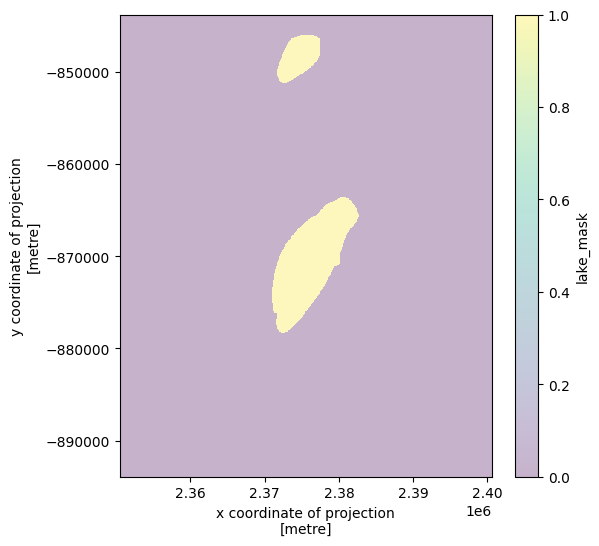

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
anomaly.plot()
mask_da.plot(alpha=0.3)

In [54]:
import os
import glob
import numpy as np
import xarray as xr
import geopandas as gpd
from rasterio.features import rasterize

existing_filePaths = glob.glob(existing_boundary_pathName)
existing_gdfs = [gpd.read_file(f).assign(lake_name=os.path.basename(f)) for f in existing_filePaths]
print(len(existing_gdfs))

new_filePaths = glob.glob(new_boundary_pathName)
new_gdfs = [gpd.read_file(f).assign(lake_name=os.path.basename(f)) for f in new_filePaths]
print(len(new_gdfs))

lakes = gpd.GeoDataFrame(pd.concat(existing_gdfs + new_gdfs, ignore_index=True))

# Ensure projection matches REMA / CryoSat
lakes = lakes.to_crs("EPSG:3031")

# Output folder
mask_out = "lake_masks/"
os.makedirs(mask_out, exist_ok=True)

35
121


Processing: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lakesTS\ANZAC19.nc
Saved: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lake_masks/ANZAC19_mask.nc
Processing: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lakesTS\Academy45.nc
Saved: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lake_masks/Academy45_mask.nc
Processing: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lakesTS\Academy91.nc
Saved: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lake_masks/Academy91_mask.nc
Processing: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lakesTS\Adams17.nc
Saved: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lake_masks/Adams17_mask.nc
Processing: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lakesTS\Adams19.nc
Saved: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lake_masks/Adams19_mask.nc
Processing: /User

C:\Users\Ashley Howard\AppData\Local\Temp\ipykernel_5004\3140857380.py:44: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6,6))


Saved: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lake_masks/David180_mask.nc
Processing: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lakesTS\David80.nc
Saved: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lake_masks/David80_mask.nc
Processing: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lakesTS\Evans158.nc
Saved: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lake_masks/Evans158_mask.nc
Processing: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lakesTS\Fisher168.nc
Saved: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lake_masks/Fisher168_mask.nc
Processing: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lakesTS\Francais36.nc
Saved: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lake_masks/Francais36_mask.nc
Processing: /Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lakesTS\Francais46.nc
Saved: /U

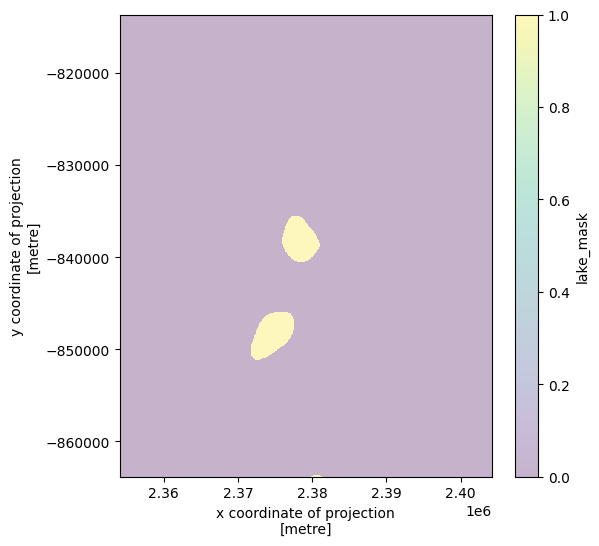

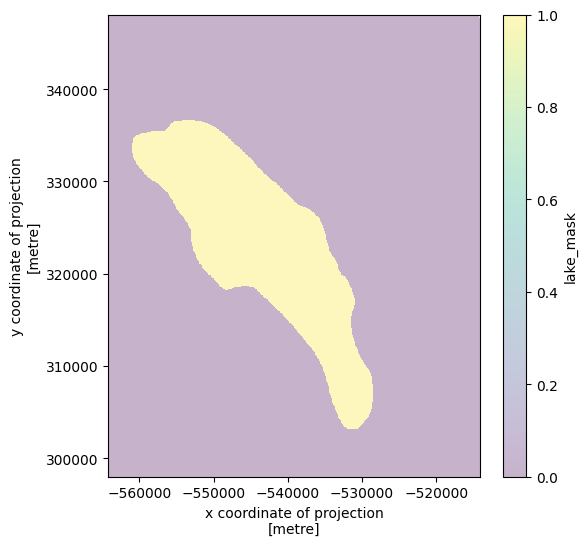

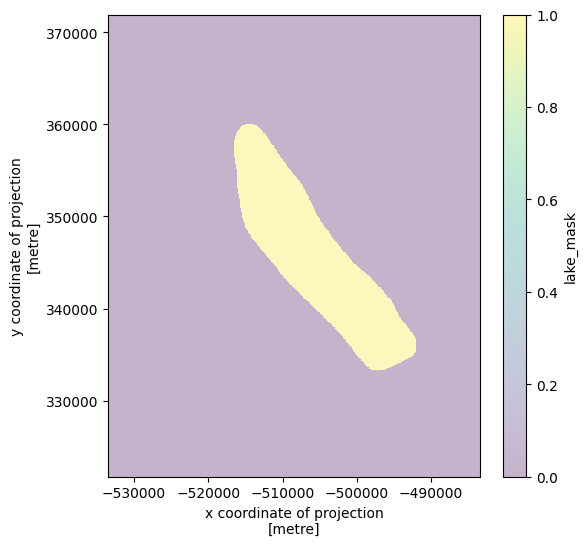

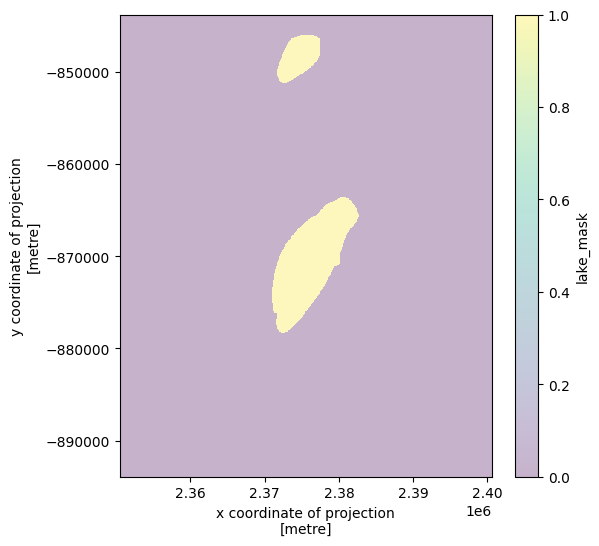

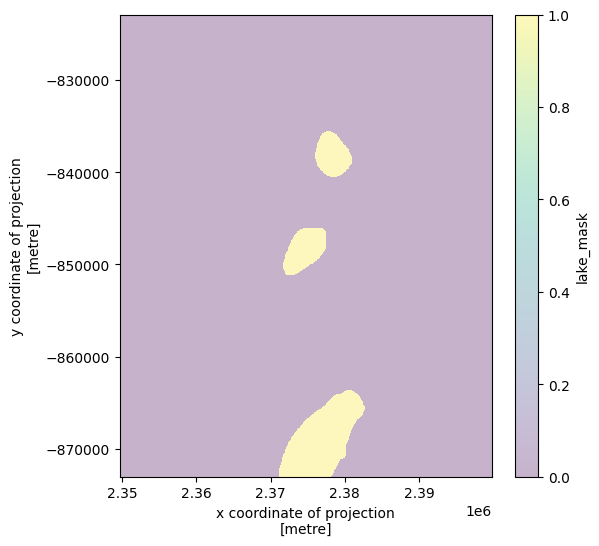

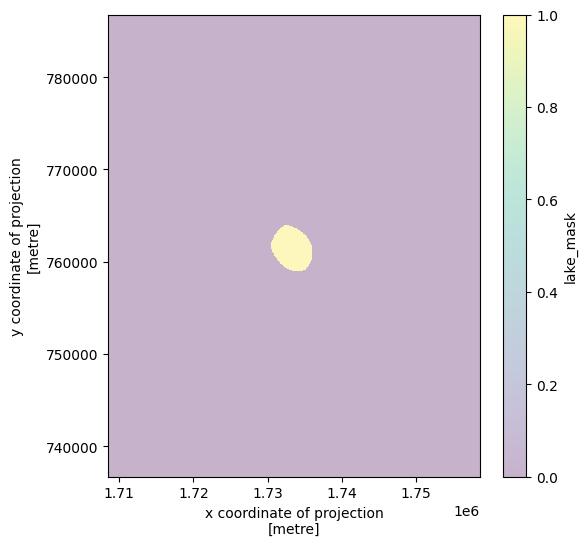

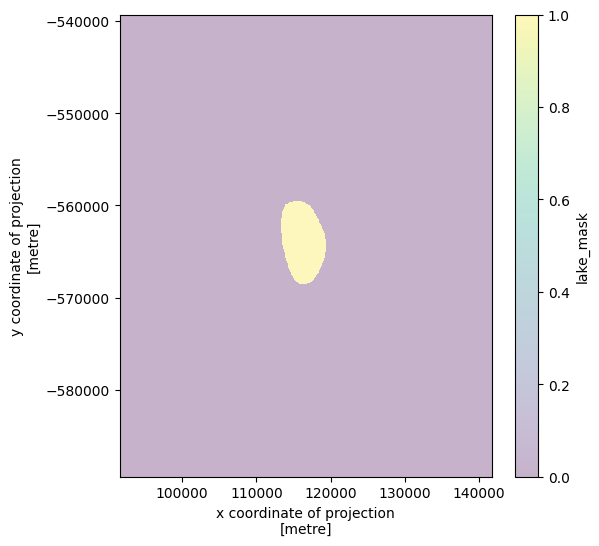

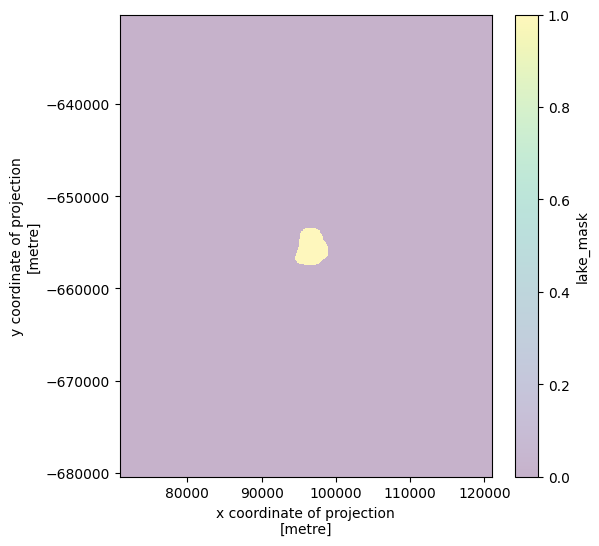

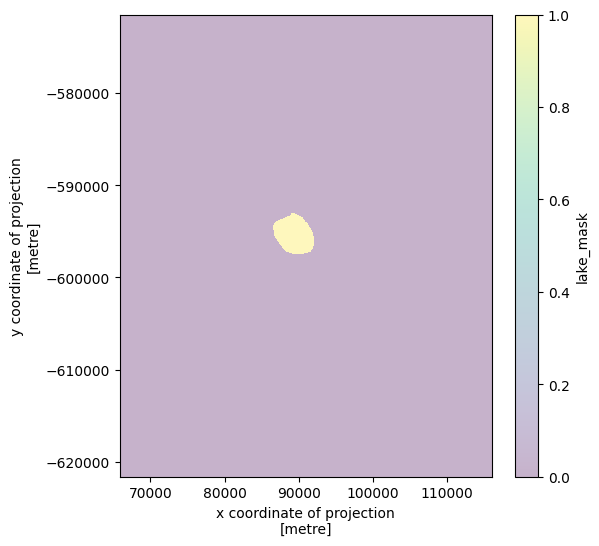

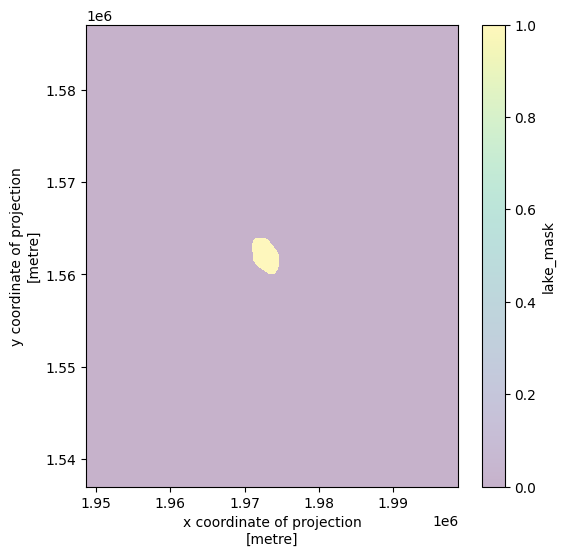

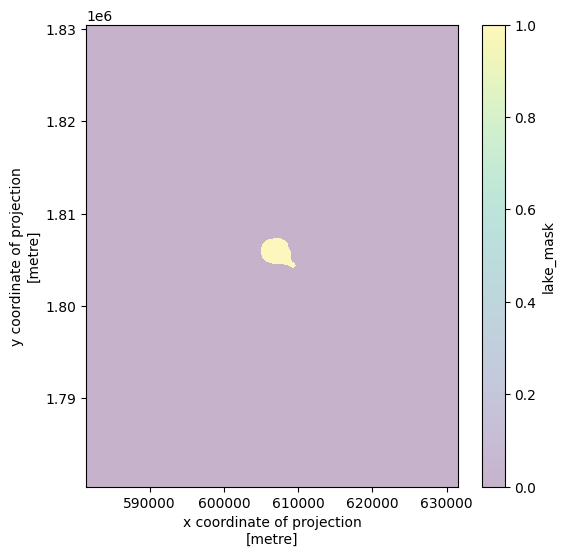

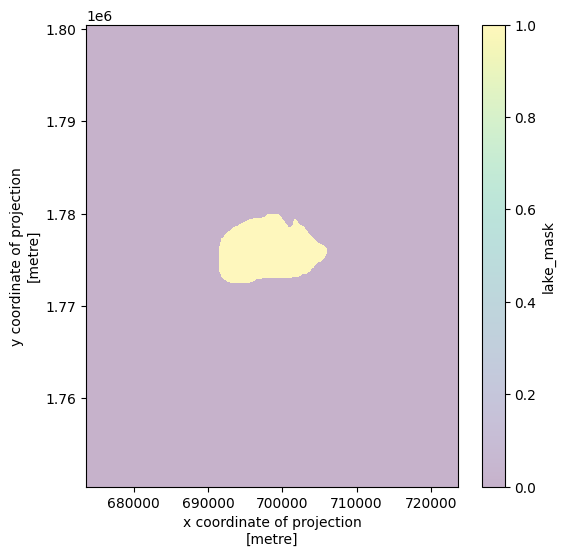

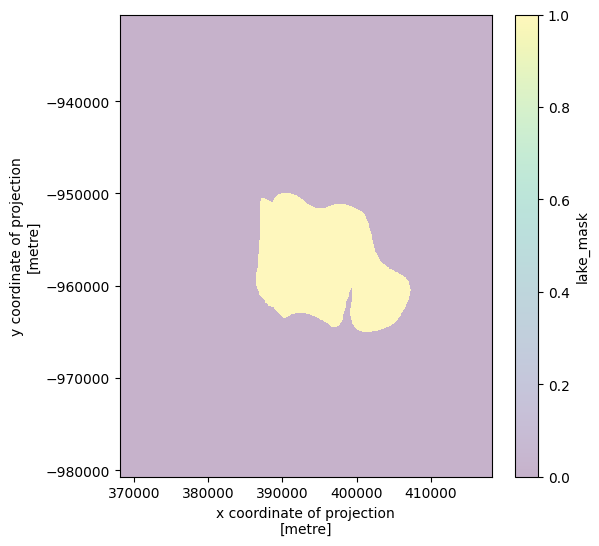

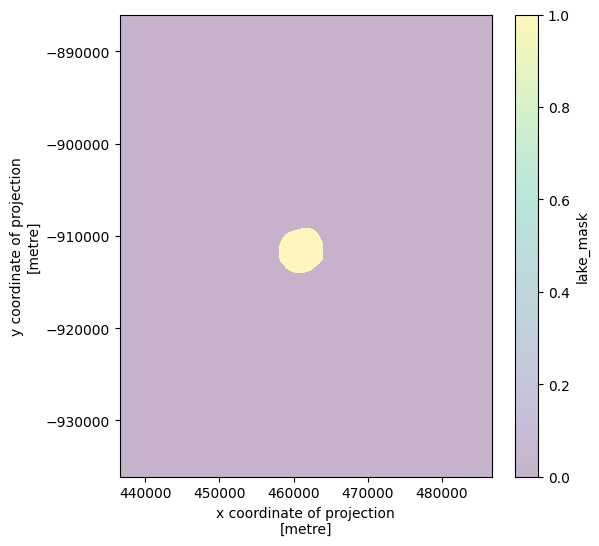

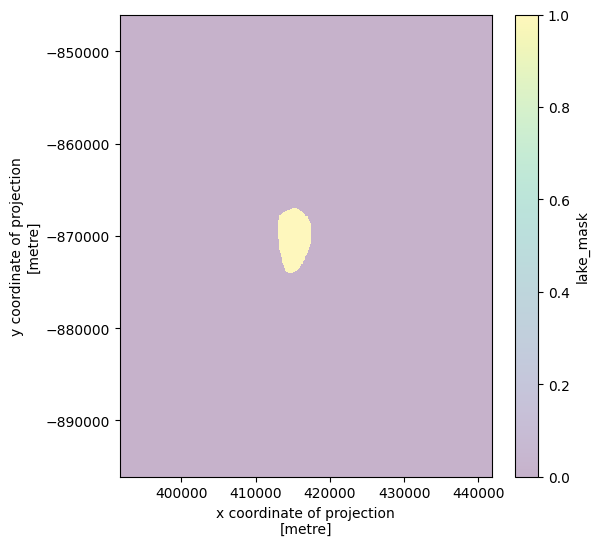

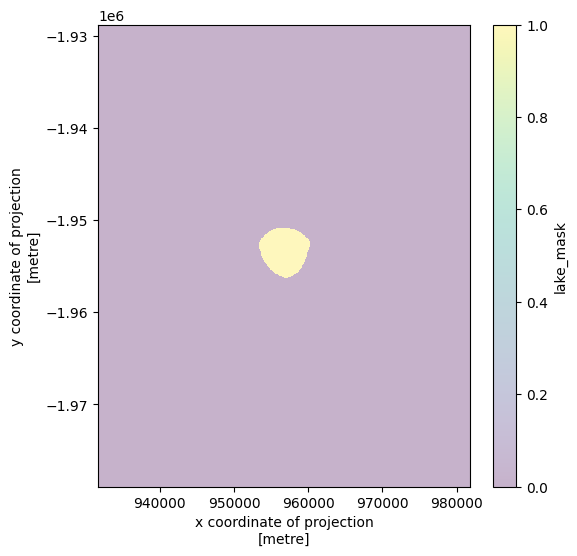

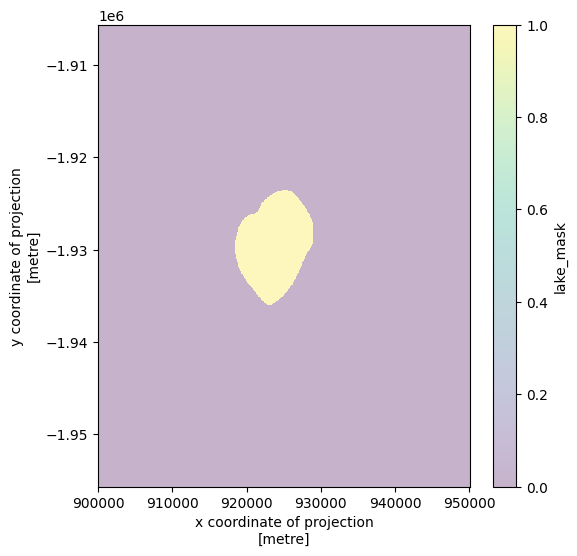

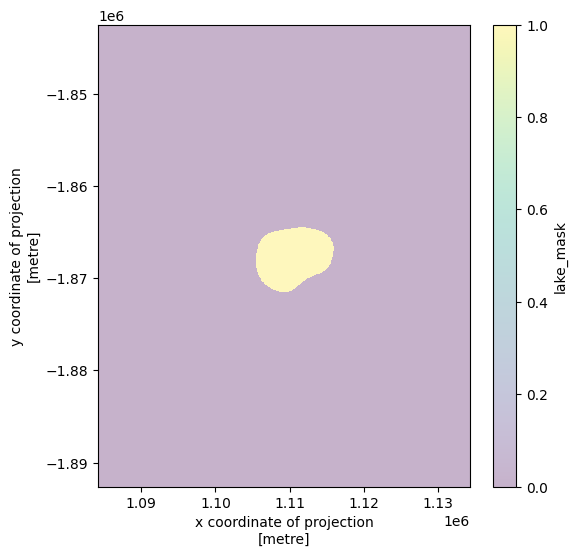

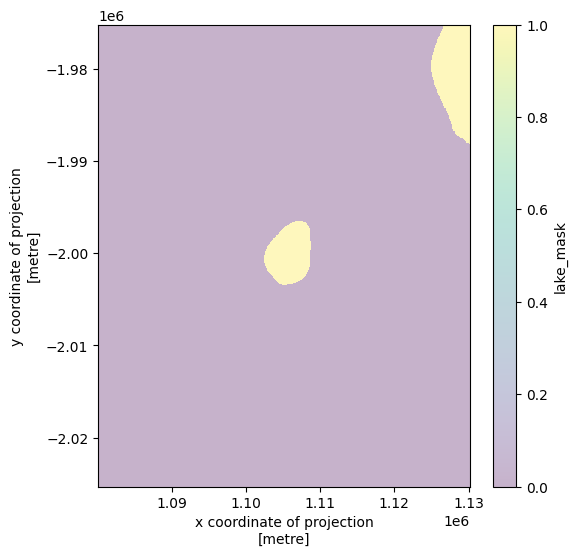

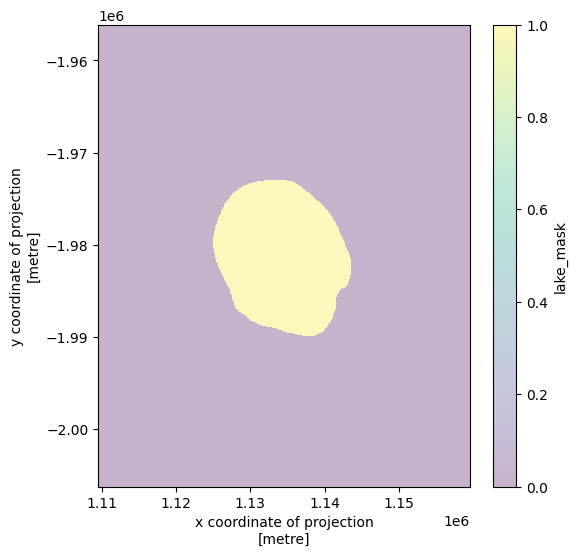

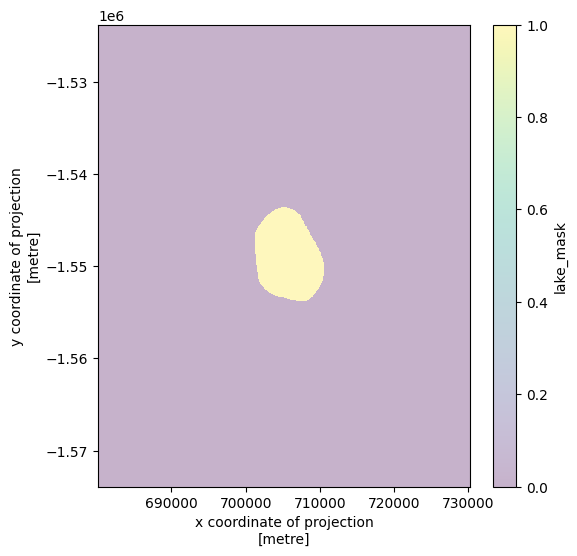

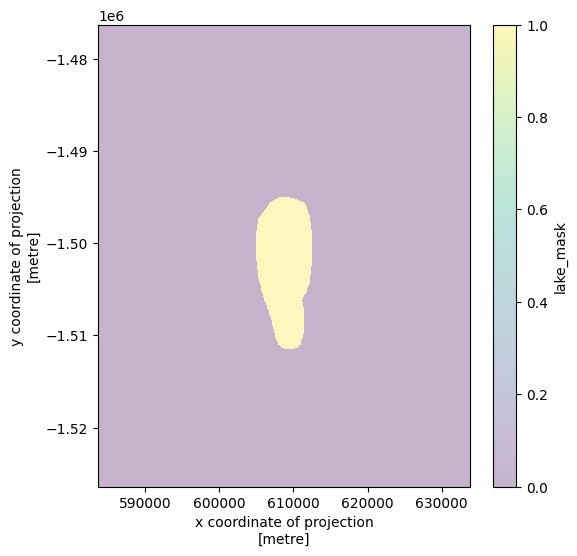

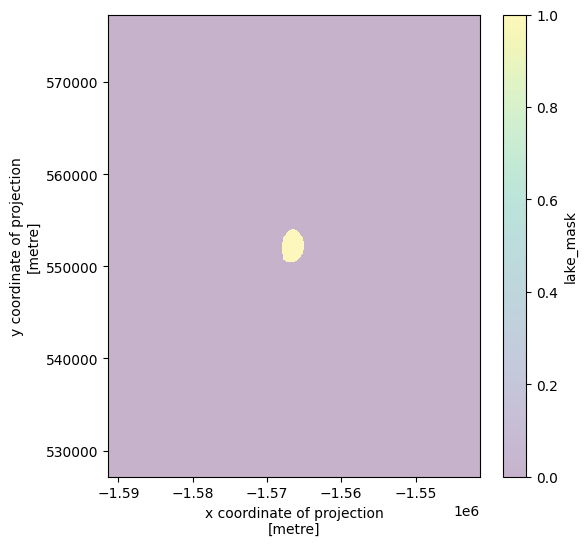

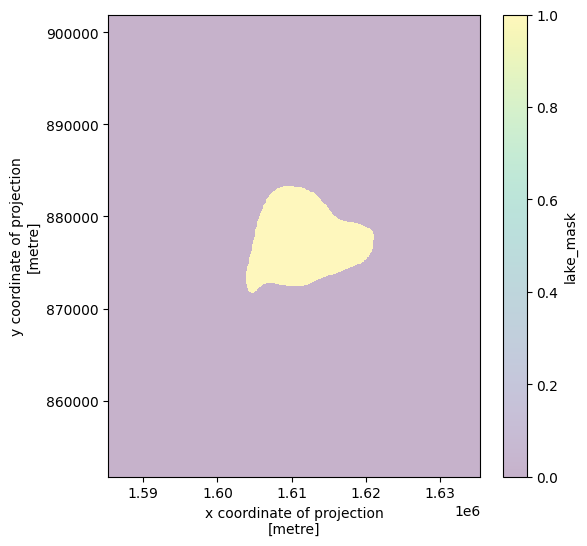

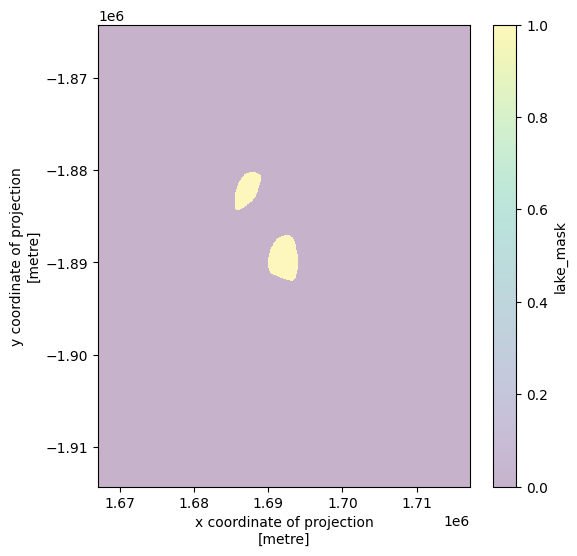

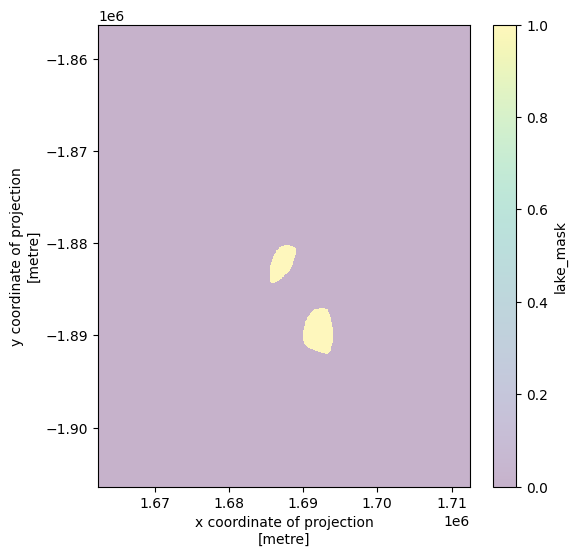

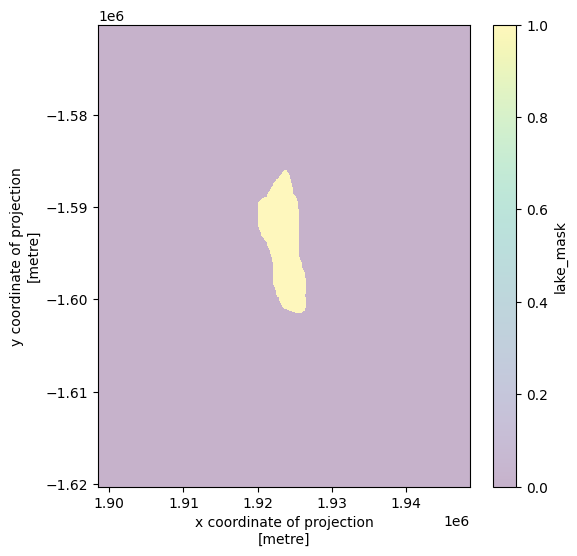

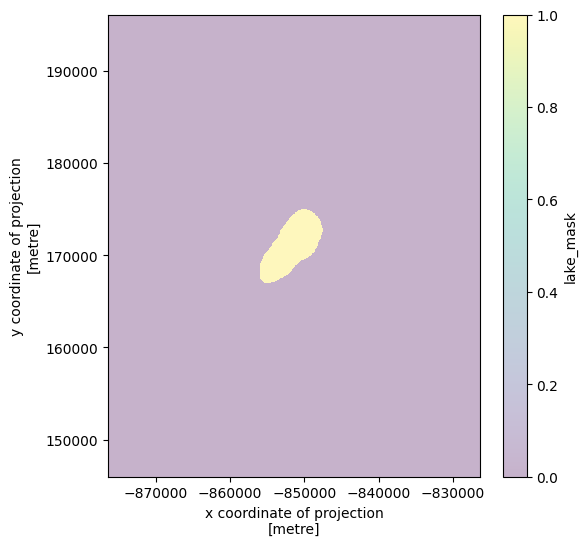

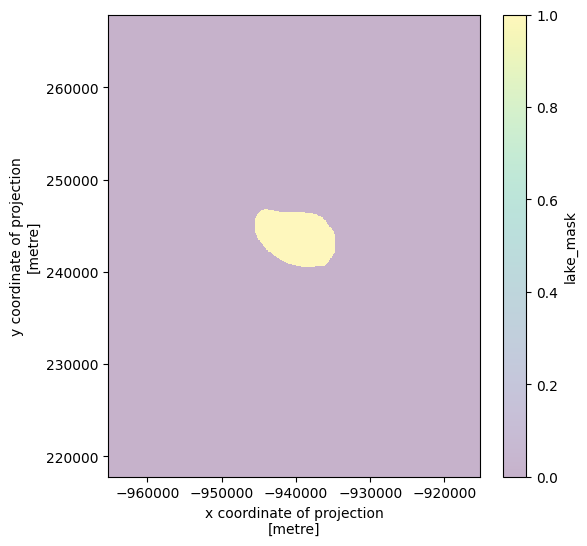

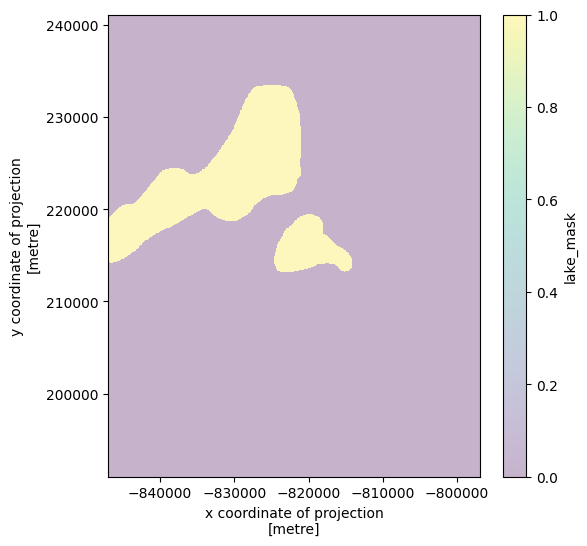

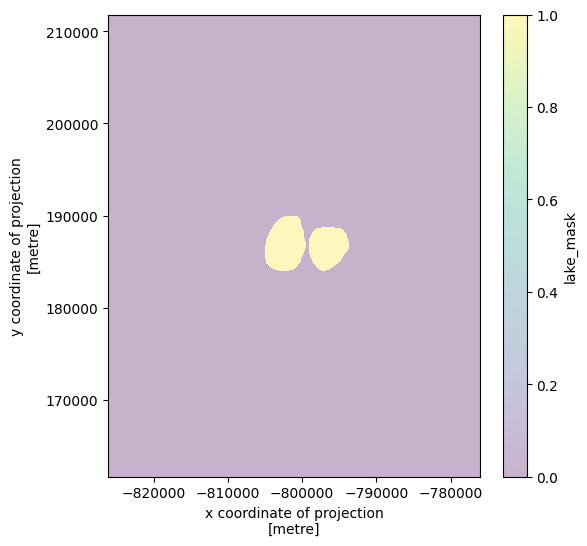

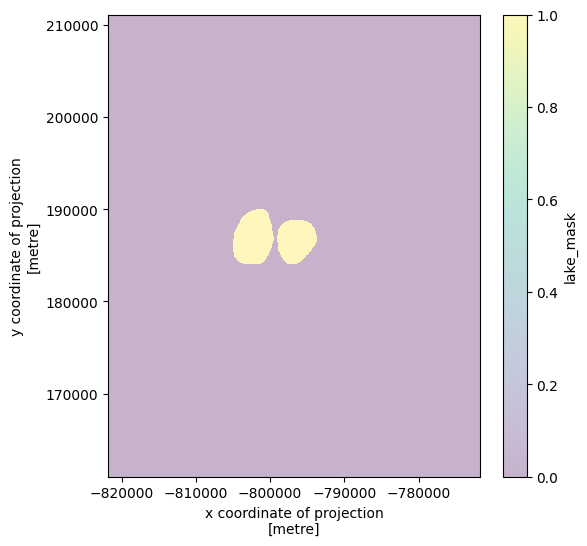

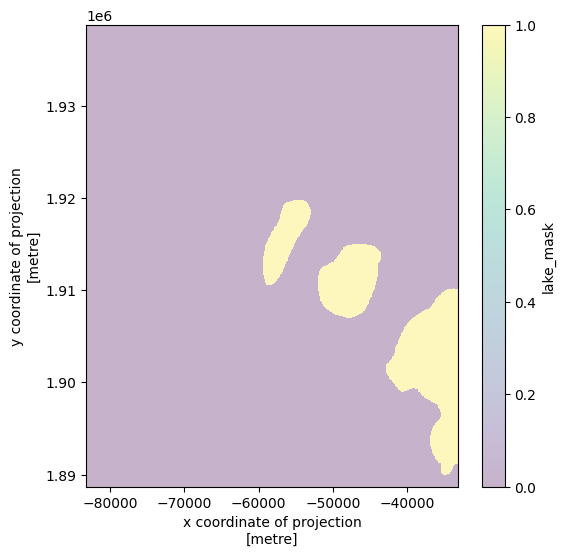

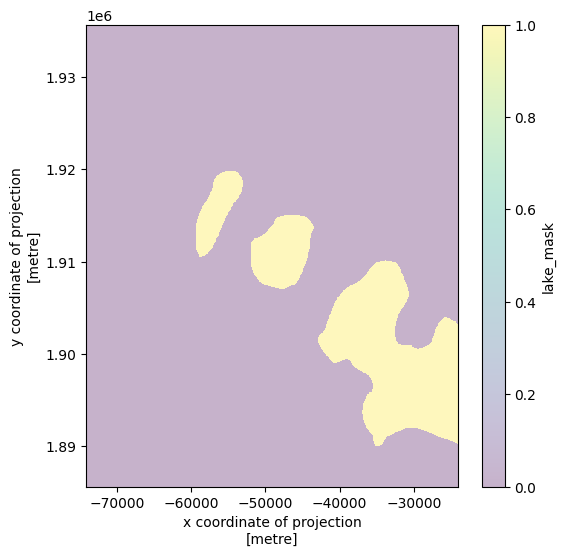

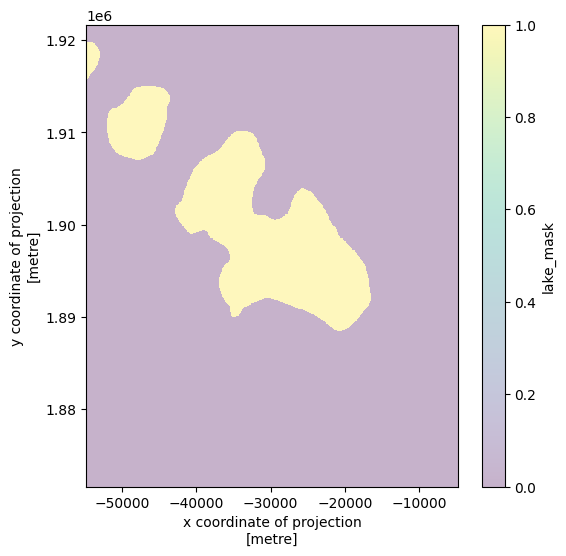

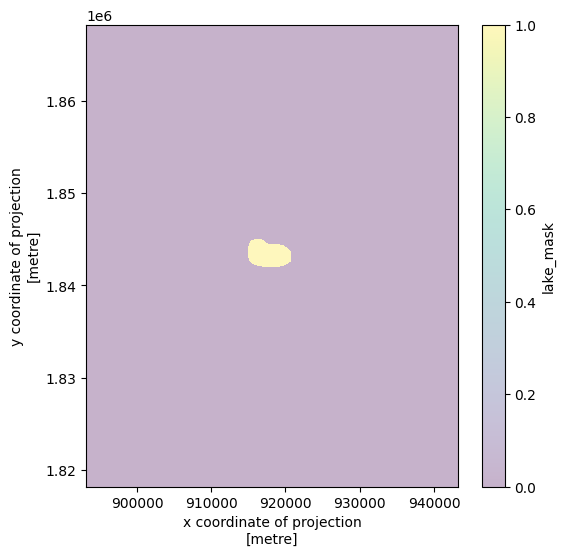

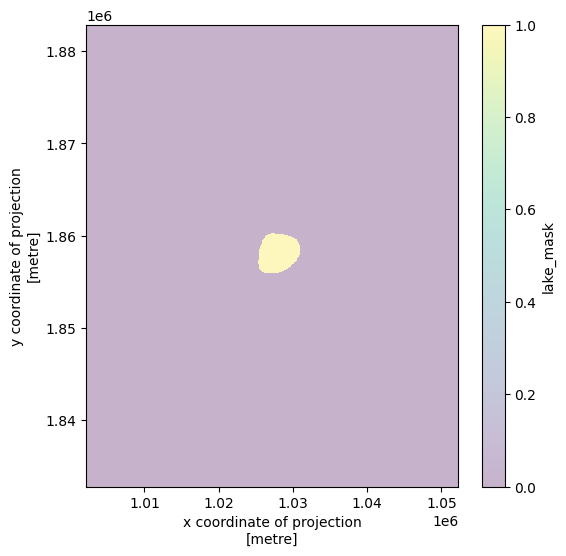

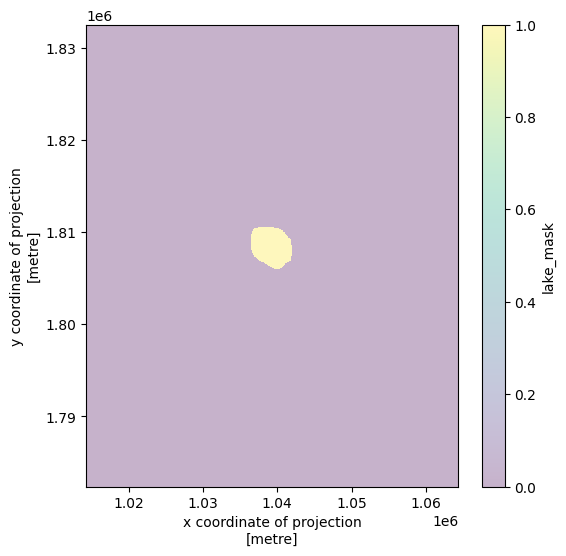

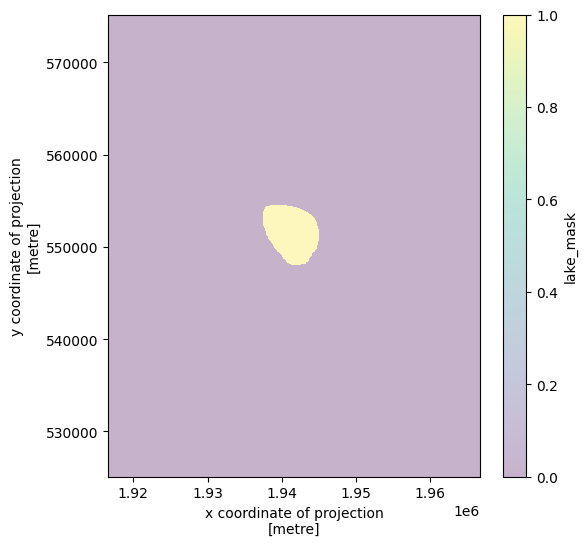

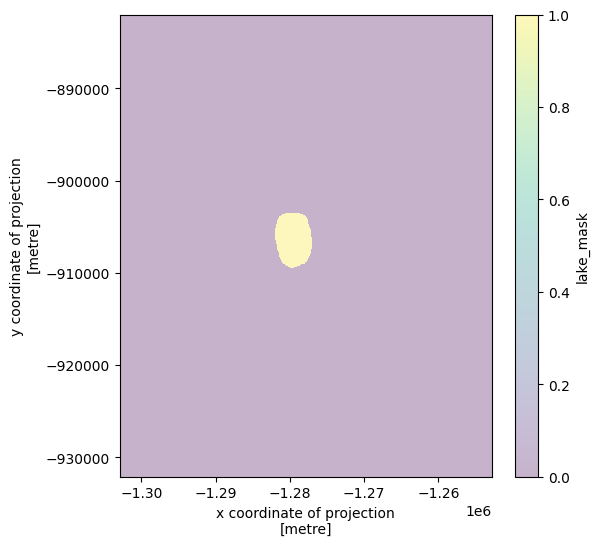

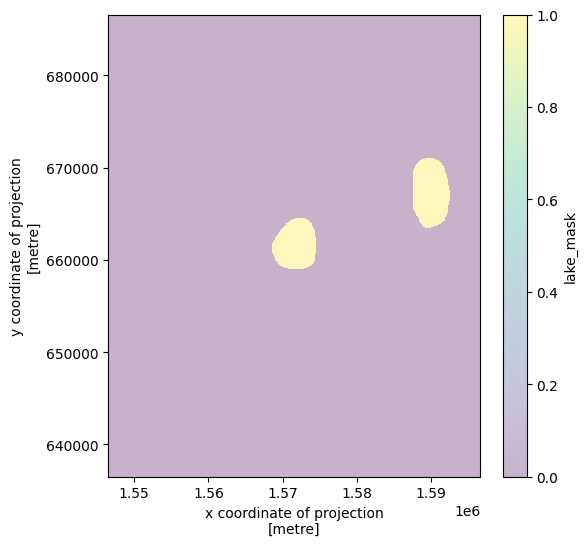

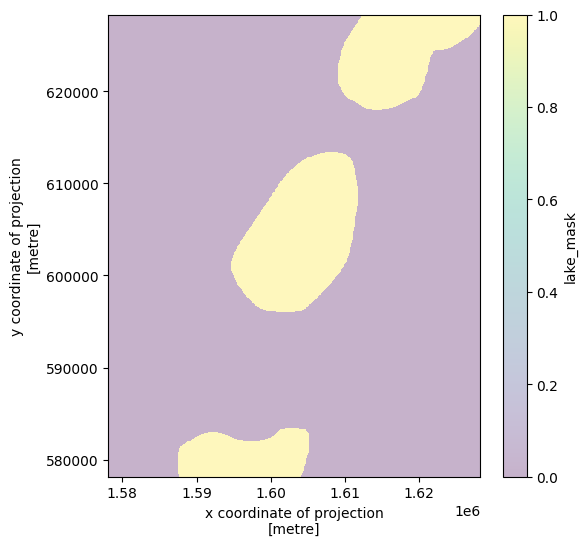

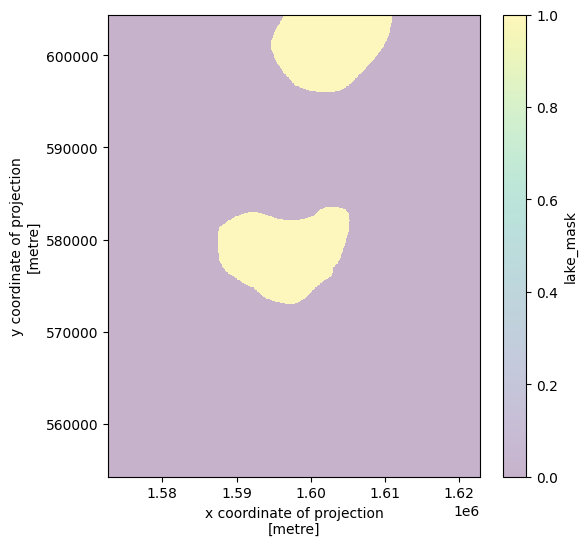

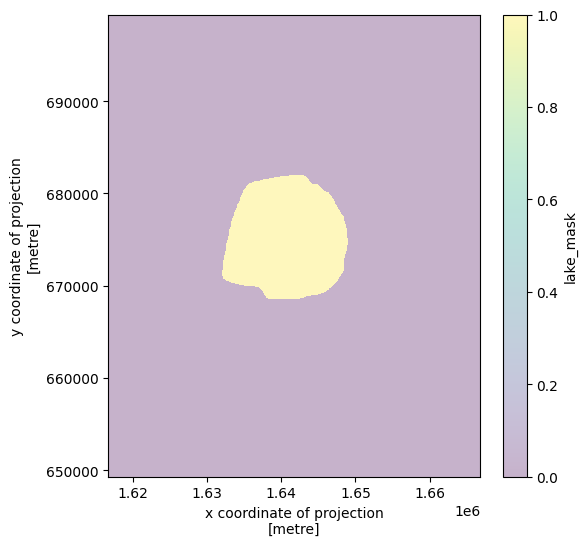

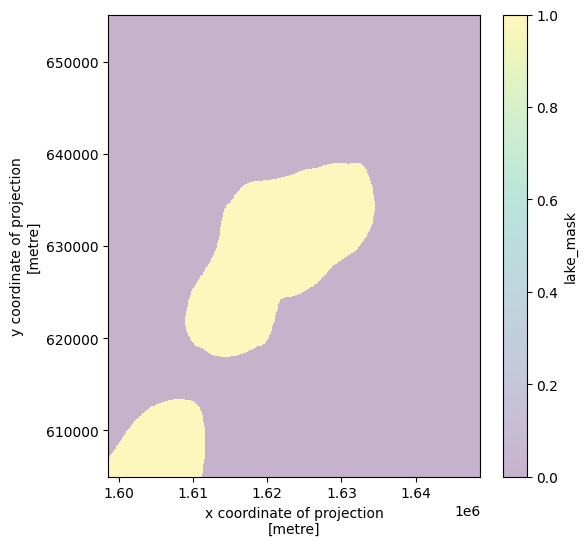

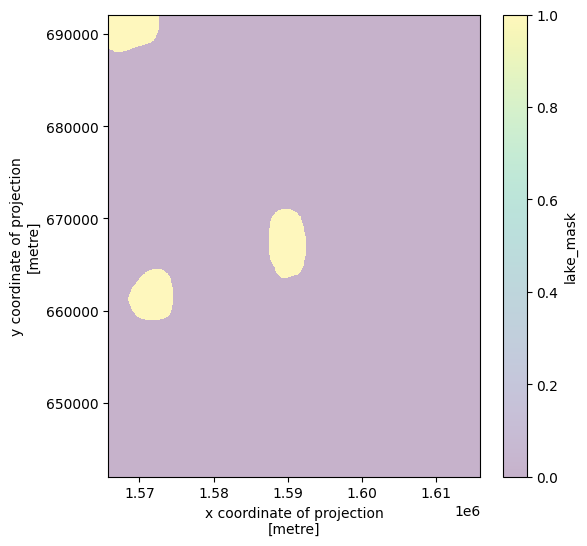

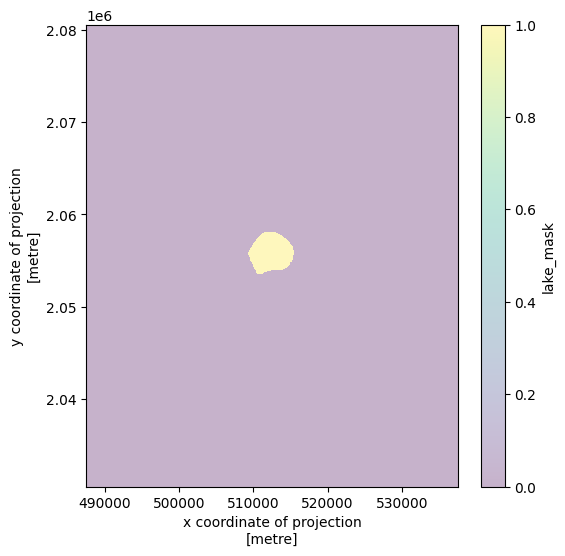

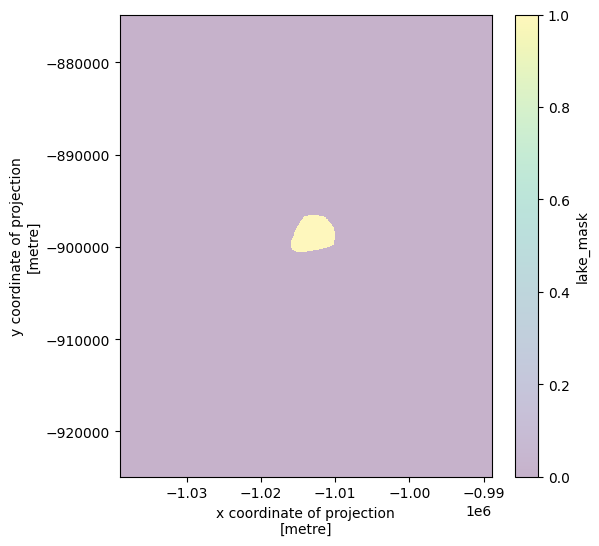

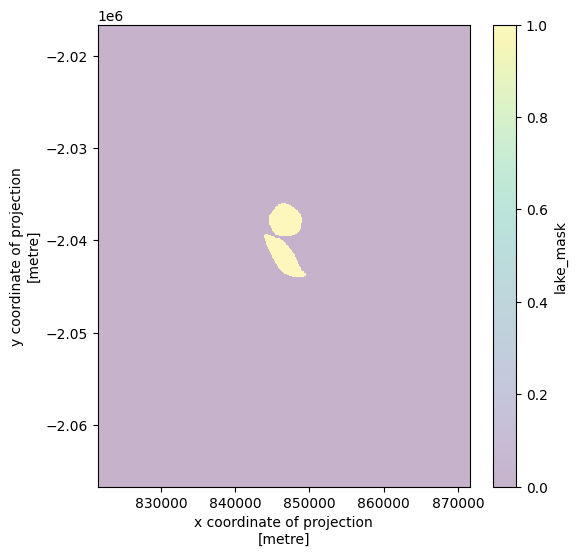

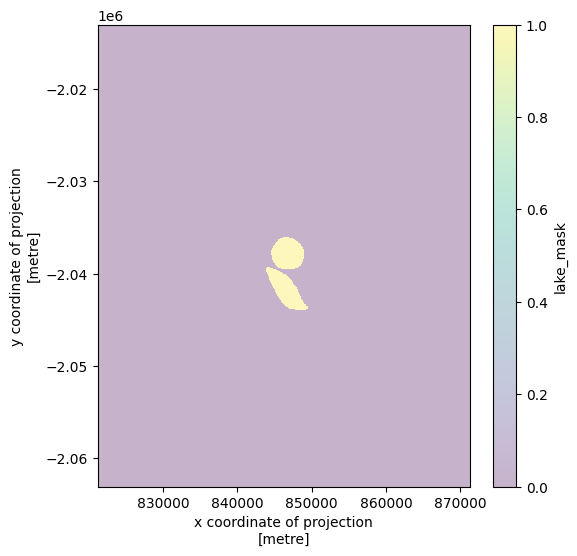

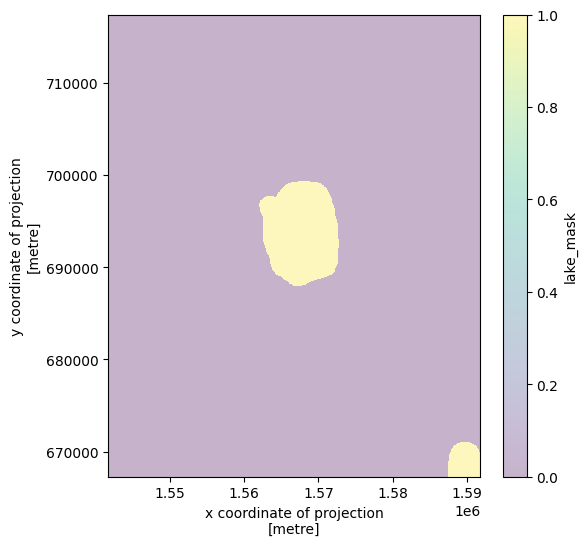

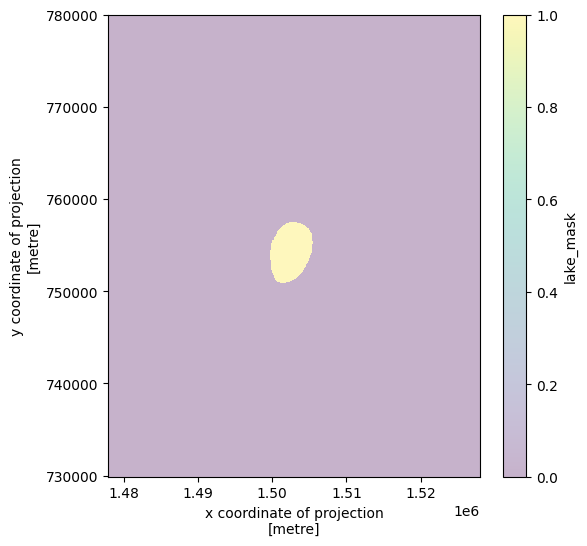

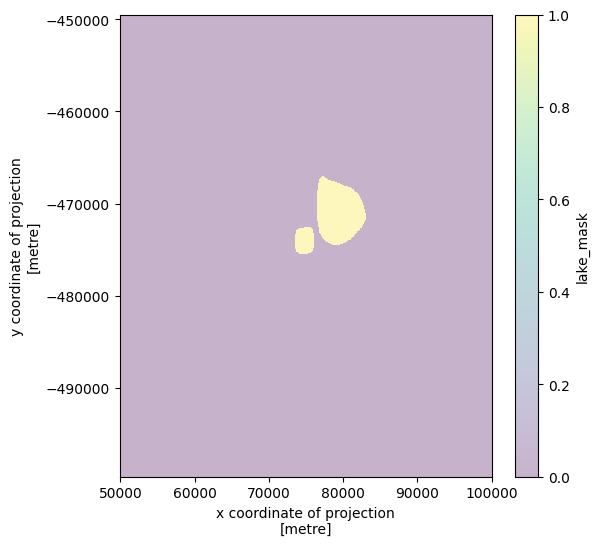

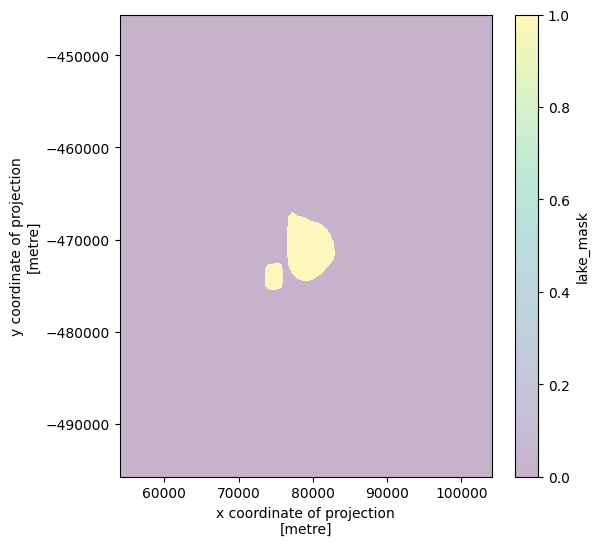

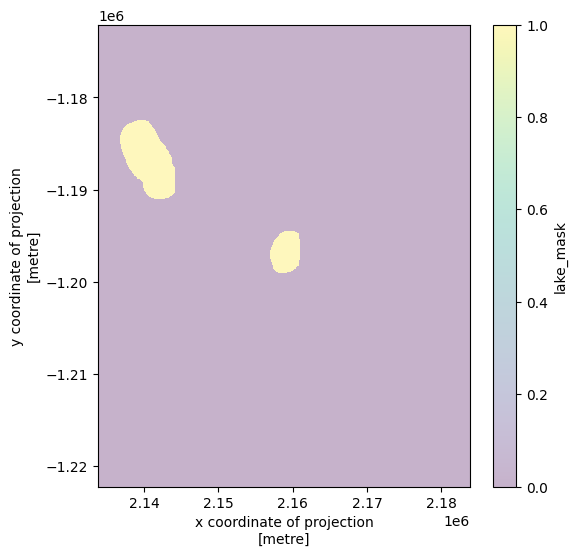

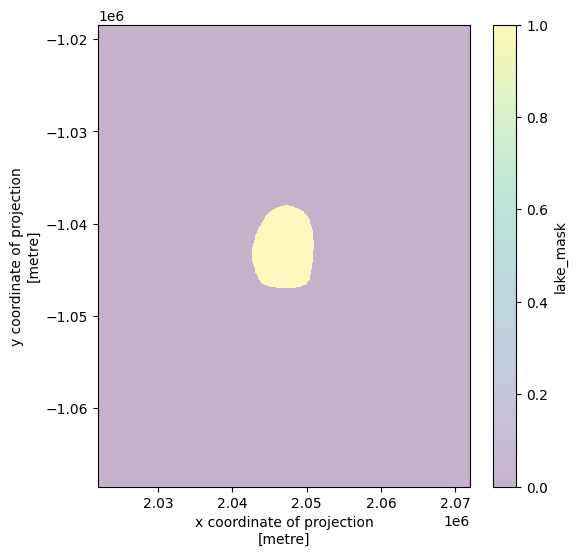

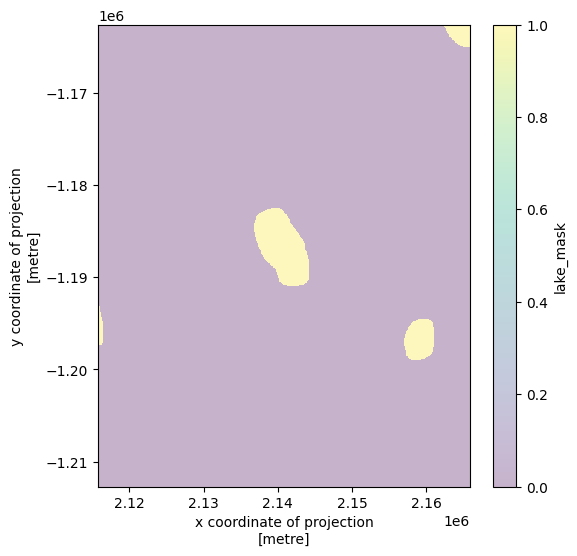

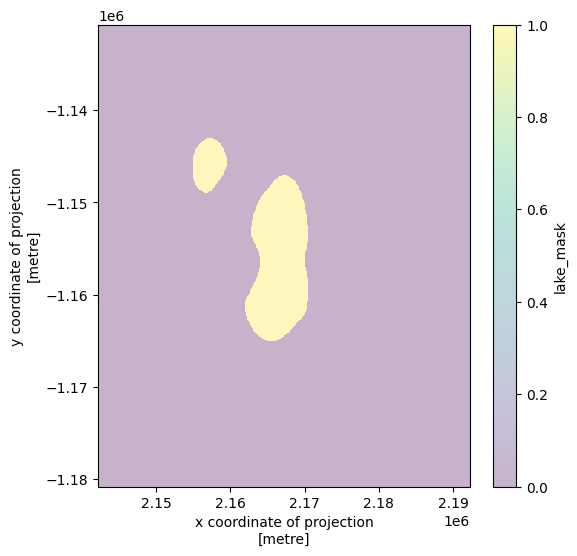

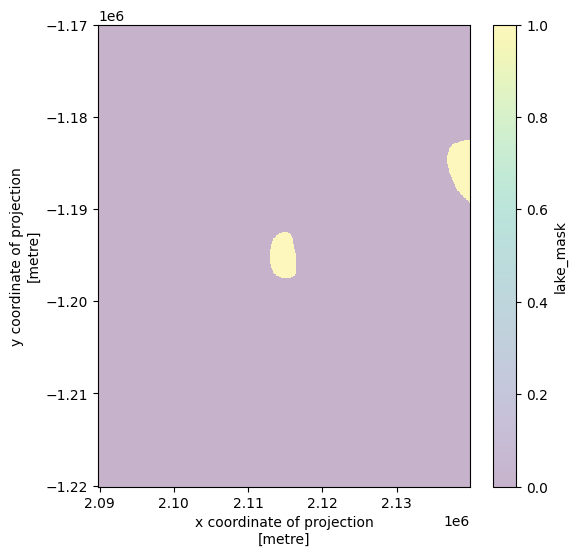

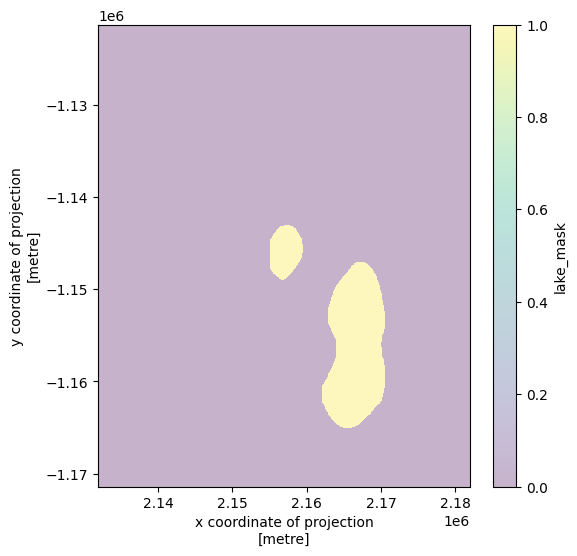

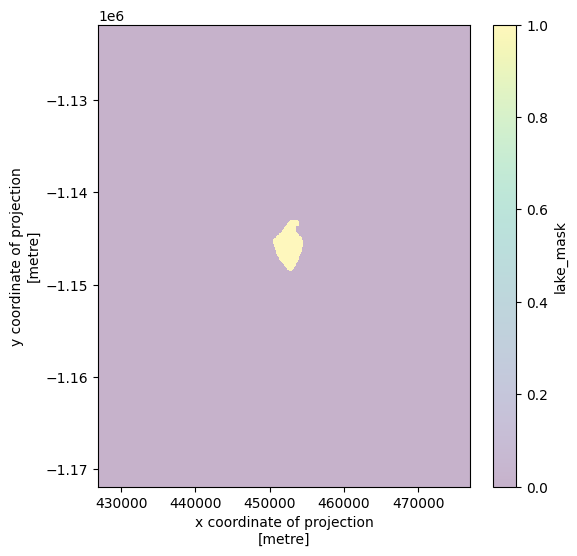

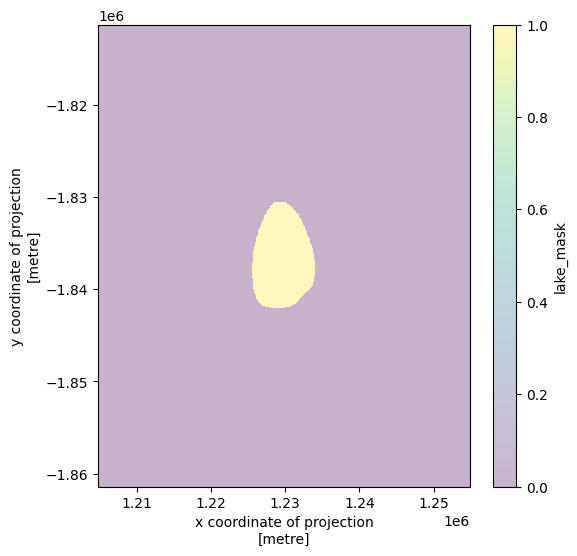

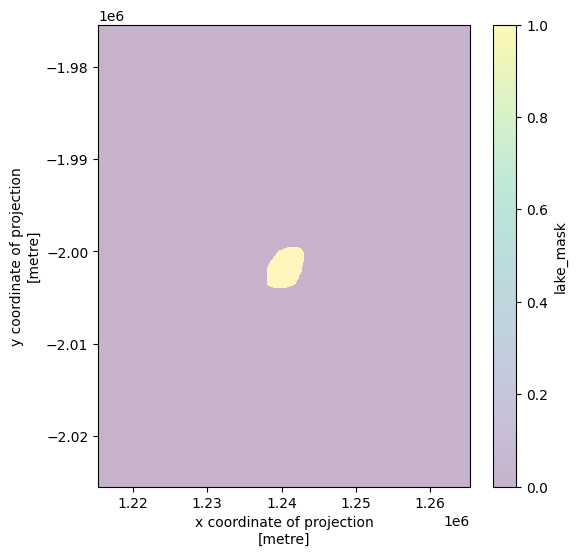

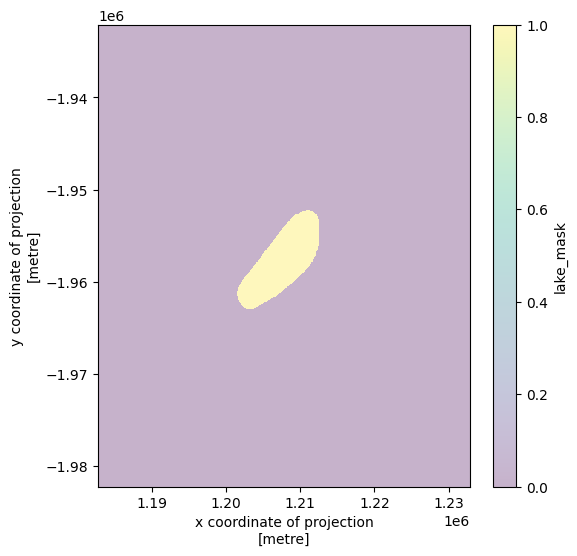

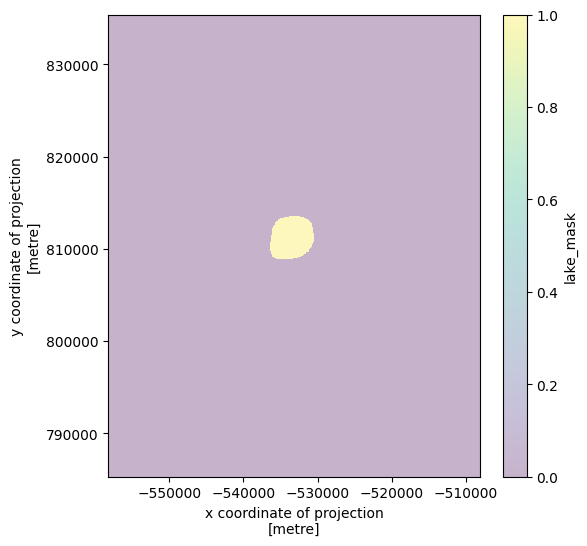

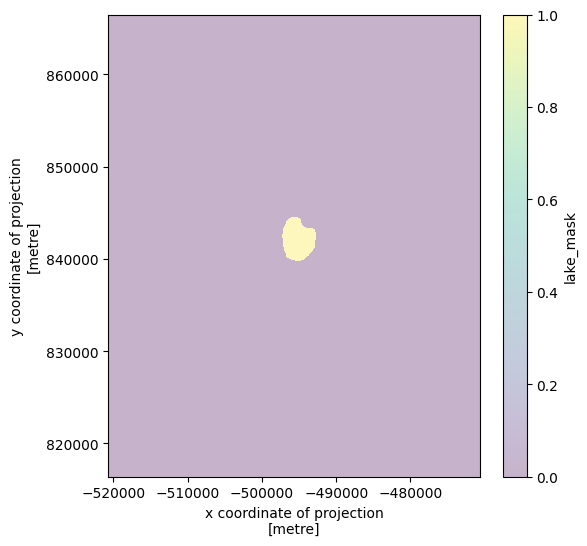

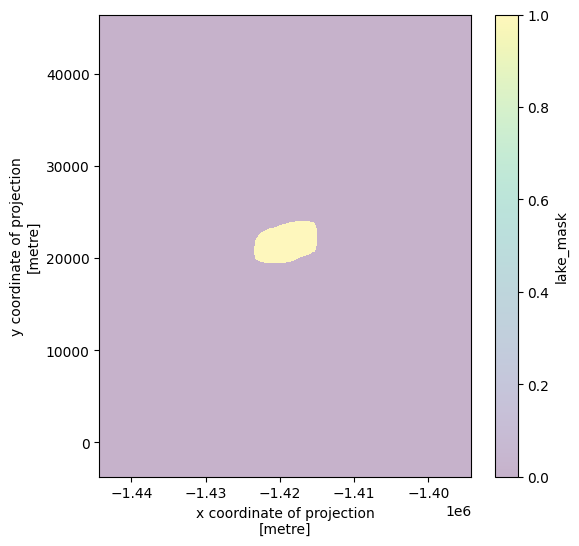

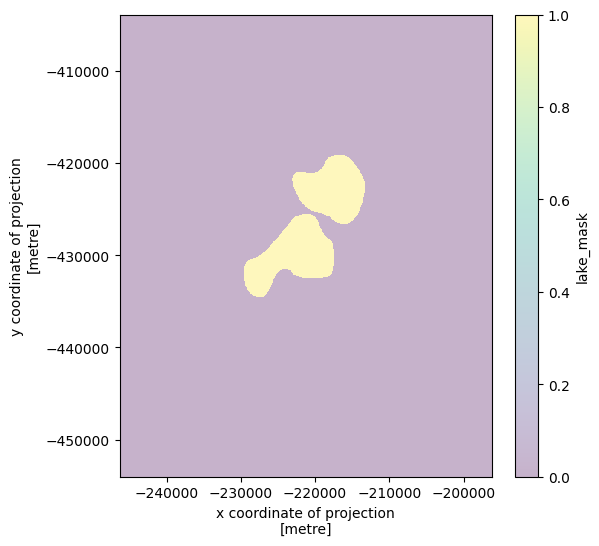

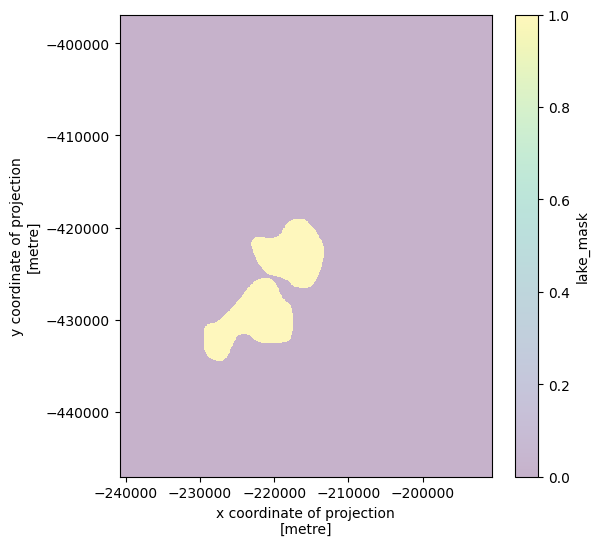

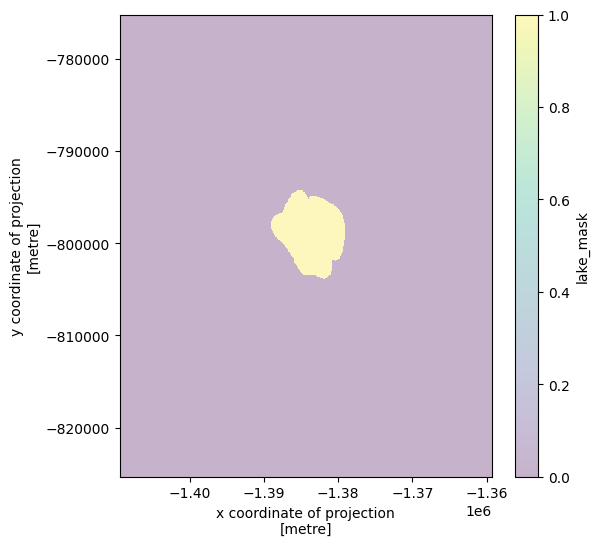

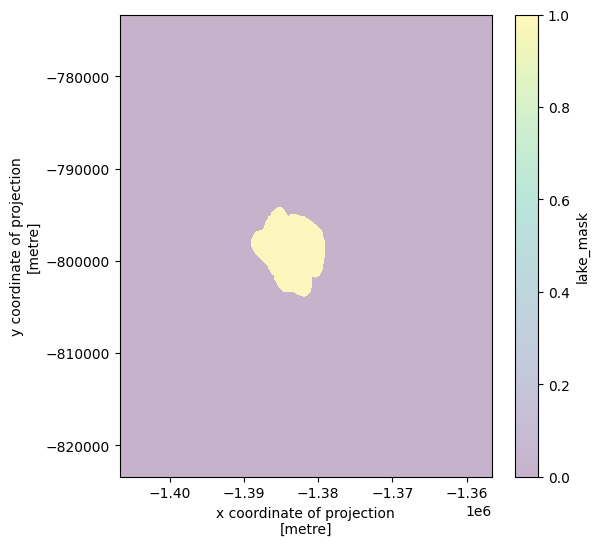

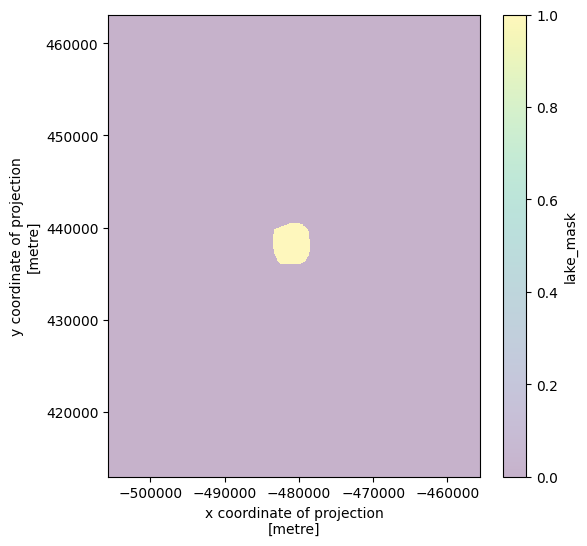

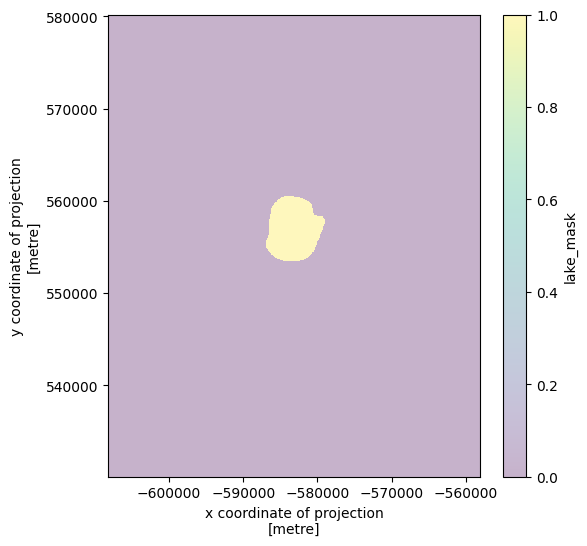

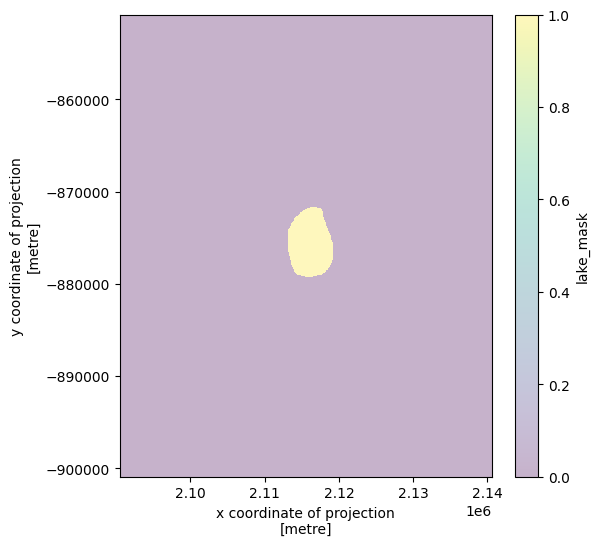

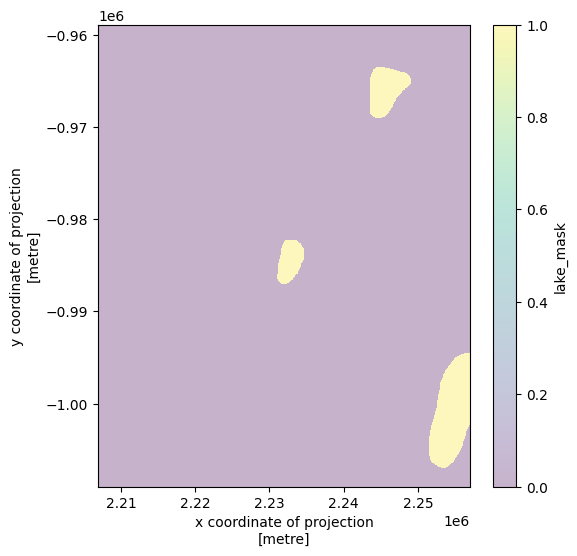

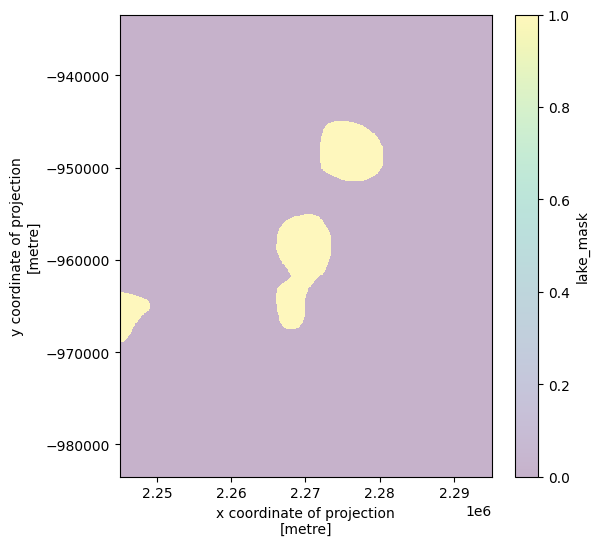

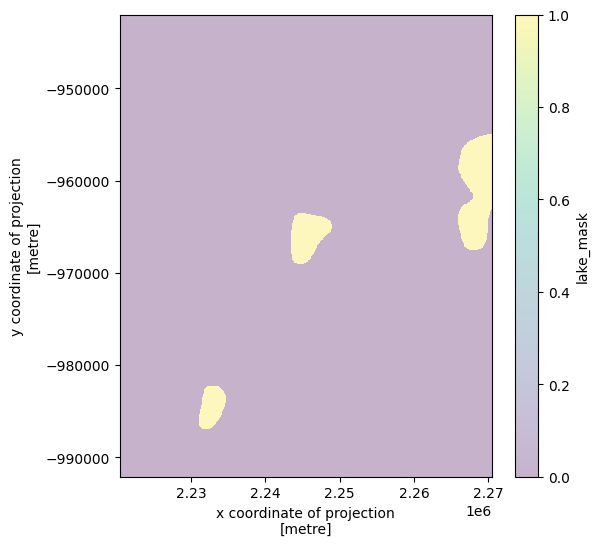

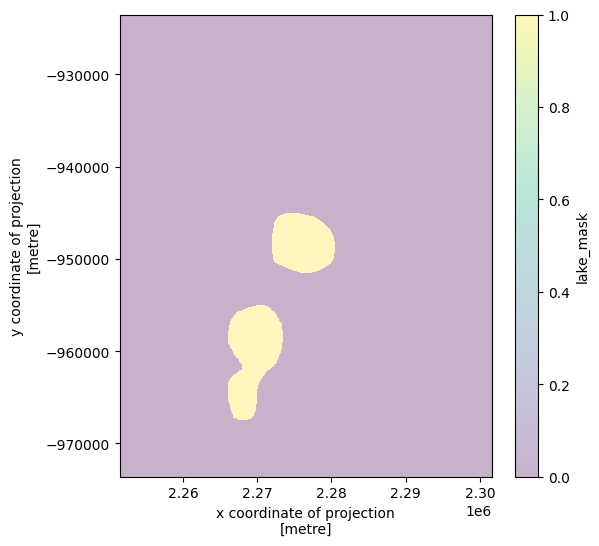

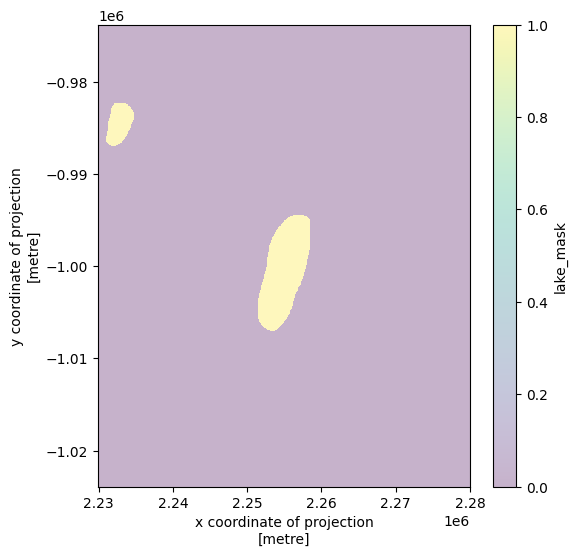

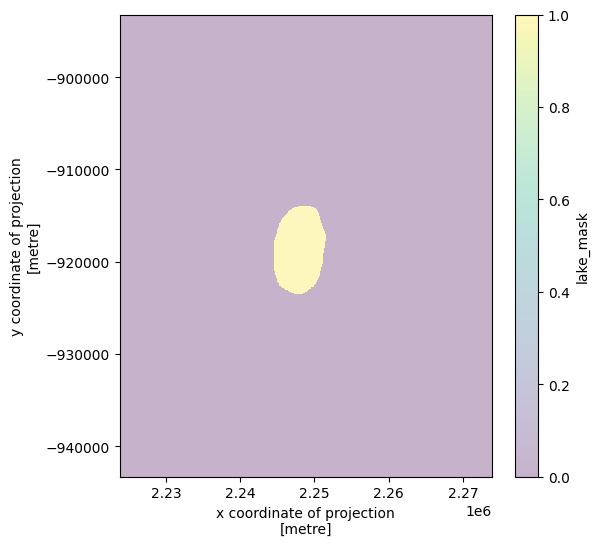

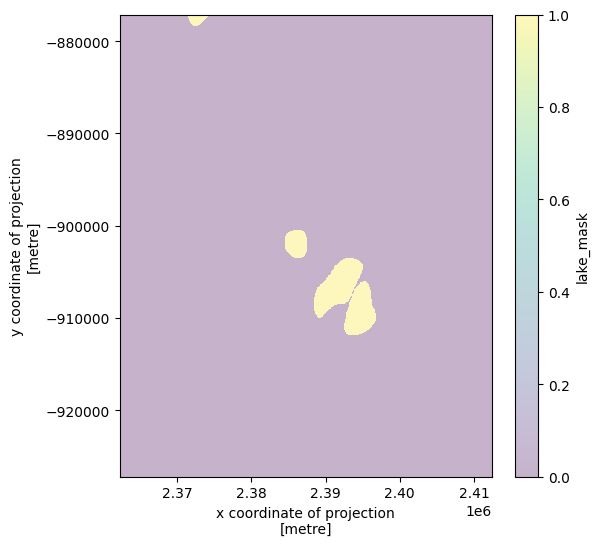

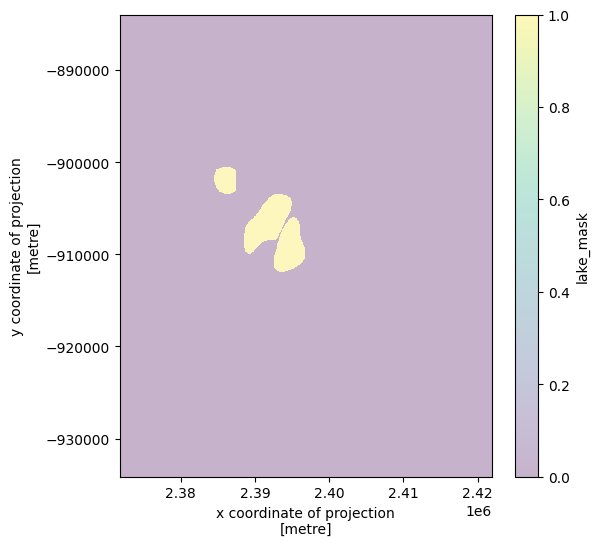

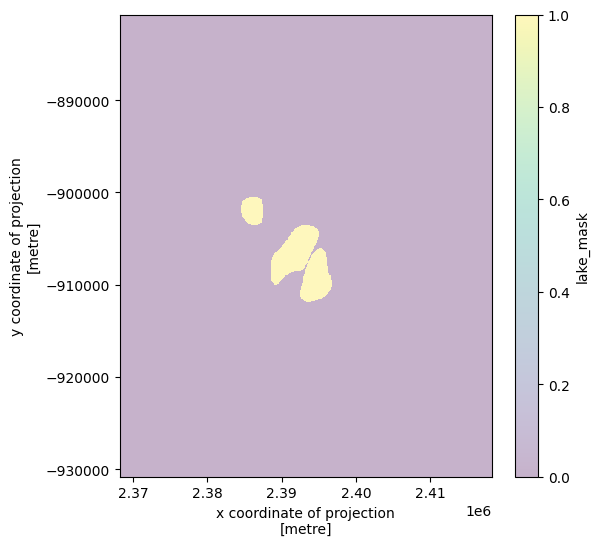

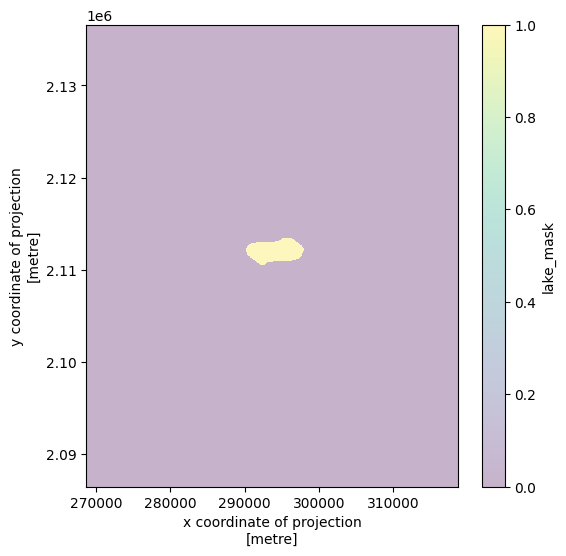

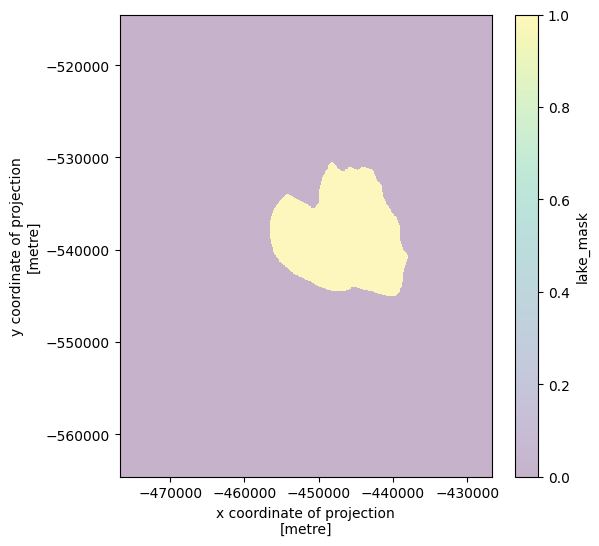

In [58]:
anomaly_folder = r'/Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lakesTS/'
mask_folder =  r'/Users/Ashley Howard/ESS569/MLGEO2026_Subglacial_Lakes/Notebooks/lake_masks/'
files = sorted(glob.glob(anomaly_folder + "*.nc"))

#do the processing for all lakes that we have tiles for (null tiles will not have a mask output)
# also localizes the mask to just the range of the tile, so multiple lakes can exist within a tile

for file in files:

    print("Processing:", file)

    ds = xr.open_dataset(file)

    # If anomaly stored in dataset
    anomaly = ds["anomaly"]

    if anomaly is None:
        continue
    xmin = float(anomaly.x.min())
    xmax = float(anomaly.x.max())
    ymin = float(anomaly.y.min())
    ymax = float(anomaly.y.max())

    # Select only lakes inside this tile
    lakes_local = lakes.cx[xmin:xmax, ymin:ymax]

    if len(lakes_local) == 0:
        print("No lakes in this tile")
        continue

    transform = anomaly.rio.transform()
    shape = (anomaly.sizes["y"], anomaly.sizes["x"])

    mask = rasterize(
        [(geom, 1) for geom in lakes_local.geometry],
        out_shape=shape,
        transform=transform,
        fill=0,
        dtype="uint8"
    )
    mask_da = xr.DataArray(
        mask,
        coords={"y": anomaly.y, "x": anomaly.x},
        dims=("y", "x"),
        name="lake_mask"
    )
    plt.figure(figsize=(6,6))
    mask_da.plot(alpha=0.3)
    base = os.path.basename(file).replace(".nc","")

    out_file = mask_folder + base + "_mask.nc"

    mask_da.to_netcdf(out_file)

    print("Saved:", out_file)